In [131]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import numpy as np
import matplotlib as mpl
import pandas as pd
import torch
import json
import sys
import os
from glob import glob
import h5py
mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['font.family'] = 'serif'
# mpl.rcParams['font.serif'] = 'Times New Roman'
mpl.rcParams['font.size'] = 9


from sample_factory.utils.utils import log

In [132]:
def compute_correlation_kernel(X, max_dx=5, max_dy=5, demean=True):
    """
    Computes a spatial correlation kernel from a 3D array X (H, W, F).
    
    Parameters:
        X: ndarray of shape (H, W, F)
        max_dx, max_dy: maximum spatial shifts in x and y
        demean: if True, subtract mean and normalize variance (z-score)
        
    Returns:
        kernel: 2D array of shape (2*max_dx+1, 2*max_dy+1) containing average correlation.
    """
    H, W, F = X.shape
    kernel = np.full((2 * max_dx + 1, 2 * max_dy + 1), np.nan)

    if demean:
        X = (X - X.mean(axis=2, keepdims=True)) / (X.std(axis=2, keepdims=True) + 1e-8)
    
    for dx in range(-max_dx, max_dx + 1):
        for dy in range(-max_dy, max_dy + 1):
            x1s, x1e = max(0, -dx), min(H, H - dx)
            y1s, y1e = max(0, -dy), min(W, W - dy)

            A = X[x1s:x1e, y1s:y1e]
            B = X[x1s + dx:x1e + dx, y1s + dy:y1e + dy]

            if demean:
                # z-scored → Pearson correlation is just dot product
                corr = np.sum(A * B, axis=-1) / F
            else:
                # use cosine similarity: (A·B) / (||A|| * ||B||)
                A_norm = np.linalg.norm(A, axis=-1)
                B_norm = np.linalg.norm(B, axis=-1)
                dot = np.sum(A * B, axis=-1)
                corr = dot / (A_norm * B_norm + 1e-8)

            kernel[dx + max_dx, dy + max_dy] = np.nanmean(corr)

    return kernel

# Gather data

In [133]:
Hippo_L = 64
Hippo_R = 8

In [134]:
folders_containing_data = ["/home/schaffert/Documents/Hippodunk/sample-factory/online_data_telemetry/InternalReward060/00_InternalReward06_see_12/telemetry",
                           "/home/schaffert/Documents/Hippodunk/sample-factory/online_data_telemetry/InternalRewardSeparateReward2/punish_1/telemetry"]

In [135]:
## aggregating data
fields_enjoys=[]
PFs_enjoys=[]
SI_enjoys=[]
percent_active=[]
percent_active_all=[]
pddata_enjoys=[]
for analysispath in folders_containing_data:
    # rootpath="/home/xiaoxiong/try0120/train_dir/ResumeLoc2_Epi_Ins9_Depth_Fix3_Tr_AR_SS_DGBN243_Hippo16_L64_skip8_3pbt_64_rollout_Gamma99_epoch2"
    # analysispath=rootpath+"/telemetry"
    glob(str(analysispath+"/*.csv"))
    

    pddata = pd.read_csv(glob(str(analysispath+"/*.csv"))[0])
    with h5py.File(glob(str(analysispath+"/*.h5"))[0]) as h5:
        activations = {k: h5[k][...] for k in h5}
    pddata['rot_pi']=pddata['rot_y']*np.pi/180
    pddata_enjoys.append(pddata)
    # activations['core']=torch.cat(activations['core'], dim=0).numpy() 
    def SpatialInformation(firing,occu,per_spike=False):
        p_occu = occu/occu.flatten().sum()
        fr_x = firing/occu
        fr_mean = firing.flatten().sum()/occu[:].sum()
        out = np.nansum((fr_x*p_occu*np.log2(fr_x/fr_mean)).flatten())
        if per_spike:
            out/=fr_mean
        return( out )
        
    ## calculate SIs
    xbound=(100,2000)
    ybound=(100,2000)
    grain = 19
    occu_xya=np.histogramdd((pddata['x'],pddata['y'],pddata['rot_pi']),(np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1),np.linspace(-np.pi,np.pi,13)),density=False)[0]

    tmp_act=activations

    # grain=19
    # hla_xya=np.zeros((grain,grain,12,128))
    # for i in range(128):
    #     hla_xya[:,:,:,i]=np.histogramdd((pddata['x'],pddata['y'],pddata['rot_pi']),(np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1),np.linspace(-np.pi,np.pi,13)),weights=tmp_act['decoder.mlp.2'][:,i]*(tmp_act['decoder.mlp.2'][:,i]>0),density=False)[0]
    # hla_xya=hla_xya[:,:,:,:]*(hla_xya[:,:,:,:]>0)

    # grain=19
    # hla0_xya=np.zeros((grain,grain,12,128))
    # for i in range(128):
    #     hla0_xya[:,:,:,i]=np.histogramdd((pddata['x'],pddata['y'],pddata['rot_pi']),(np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1),np.linspace(-np.pi,np.pi,13)),weights=tmp_act['decoder.mlp.0'][:,i]*(tmp_act['decoder.mlp.0'][:,i]>0),density=False)[0]
    # hla0_xya=hla0_xya[:,:,:,:]*(hla0_xya[:,:,:,:]>0)

    if tmp_act['core'].shape[1]-13 != 16*(Hippo_L+Hippo_R-1):
        print('size mismatch!!!!')
        break
    sids=tmp_act['core'][:,:-13:(Hippo_L+Hippo_R-1)]
    perc=(sids>0).mean(0)
    percent_active.append(perc)
    percent_active_all.append((sids.sum(1)>0).mean())
    
    grain=19
    seq0_xya=np.zeros((grain,grain,12,16))
    for i in range(16):
        seq0_xya[:,:,:,i]=np.histogramdd((pddata['x'],pddata['y'],pddata['rot_pi']),(np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1),np.linspace(-np.pi,np.pi,13)),weights=sids[:,i],density=False)[0]

    grain=19
    seqall_xya=np.zeros((grain,grain,12,16*(Hippo_L+Hippo_R-1)))
    for i in range(16*(Hippo_L+Hippo_R-1)):
        seqall_xya[:,:,:,i]=np.histogramdd((pddata['x'],pddata['y'],pddata['rot_pi']),(np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1),np.linspace(-np.pi,np.pi,13)),weights=tmp_act['core'][:,i],density=False)[0]

    fields = {"seq0":seq0_xya,"seqall":seqall_xya,"occu":occu_xya}
    # fields = {"mlp0":hla0_xya,"mlp2":hla_xya,"seq0":seq0_xya,"seqall":seqall_xya,"occu":occu_xya}
    fields_enjoys.append(fields)

    SIs = dict()
    for key in fields:
        if key !="occu":
            SIs[key]= np.array([SpatialInformation(fields[key][:,:,:,i],fields["occu"]) for i in range(fields[key].shape[-1])])
    SI_enjoys.append(SIs)
    PFs = dict()
    for key in fields:
        if key !="occu":
            PFs[key]= np.nansum(fields[key],-2)/np.nansum(fields["occu"][:,:,:,None],-2)
    PFs_enjoys.append(PFs)
    # SI_mlp2=np.array([SpatialInformation(hla_xya[:,:,:,i],occu_xya) for i in range(128)])
    # SI_seq0=np.array([SpatialInformation(seq0_xya[:,:,:,i],occu_xya) for i in range(16)])
    # SI_seqall=np.array([SpatialInformation(seqall_xya[:,:,:,i],occu_xya) for i in range(16*15)])
    


/tmp/ipykernel_483154/2824972911.py:22: RuntimeWarning: invalid value encountered in divide
  fr_x = firing/occu
/tmp/ipykernel_483154/2824972911.py:24: RuntimeWarning: divide by zero encountered in log2
  out = np.nansum((fr_x*p_occu*np.log2(fr_x/fr_mean)).flatten())
/tmp/ipykernel_483154/2824972911.py:24: RuntimeWarning: invalid value encountered in multiply
  out = np.nansum((fr_x*p_occu*np.log2(fr_x/fr_mean)).flatten())
/tmp/ipykernel_483154/2824972911.py:79: RuntimeWarning: invalid value encountered in divide
  PFs[key]= np.nansum(fields[key],-2)/np.nansum(fields["occu"][:,:,:,None],-2)
/tmp/ipykernel_483154/2824972911.py:22: RuntimeWarning: invalid value encountered in divide
  fr_x = firing/occu
/tmp/ipykernel_483154/2824972911.py:24: RuntimeWarning: divide by zero encountered in log2
  out = np.nansum((fr_x*p_occu*np.log2(fr_x/fr_mean)).flatten())
/tmp/ipykernel_483154/2824972911.py:24: RuntimeWarning: invalid value encountered in multiply
  out = np.nansum((fr_x*p_occu*np.log2

# Plotting
## spatial Kernel

In [136]:
xygrain=19
layernames=['seq0', 'seqall']#,'mlp0', 'mlp2' ]
displayname_dict={'seq0':'DG','seqall':'CA3'}#,'mlp0':'Decoder 1','mlp2':'Decoder 2'}

In [137]:
Spatial_kernel=dict()
for key in PFs_enjoys[0]:
    tmpPFs_enjoys=np.array([x[key] for x in PFs_enjoys])
    # tmpPFs_enjoys=tmpPFs_enjoys.reshape(tmpPFs_enjoys.shape[0],-1,tmpPFs_enjoys.shape[-1])
    tmp_kernels=np.zeros((8,2*xygrain-1,2*xygrain-1))
    for epoch in range(len(PFs_enjoys)):
        tmp=tmpPFs_enjoys[epoch,:,:,:]

        tmp_kernels[epoch,:,:]=compute_correlation_kernel(tmp, max_dx=xygrain-1, max_dy=xygrain-1)
    Spatial_kernel[key]=tmp_kernels
    #     for i in range(xygrain):
    #         for j in range(xygrain):
    #             tmp_kernels[epoch,i,j]=np.array([pd.DataFrame(tmp[i,j]).corr()

    # np.array([pd.DataFrame(tmpPFs_enjoys[:,i,:].T).corr() for i in range(tmpPFs_enjoys.shape[1])])

/tmp/ipykernel_483154/1109611696.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.96, 1],pad=0.01)


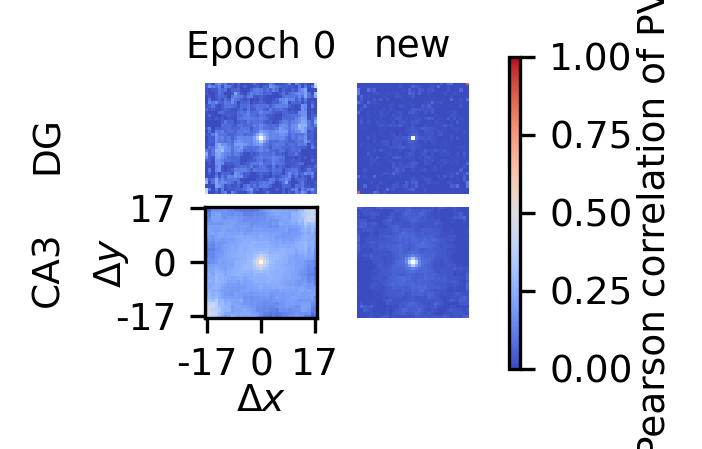

In [138]:
import numpy as np
import matplotlib.pyplot as plt

layer_names = list(Spatial_kernel.keys())
n_layers = len(layer_names)
n_epochs = 2

# Create the grid of axes
fig, ax = plt.subplots(n_layers, n_epochs,
                       figsize=(n_epochs*0.65+0.5, n_layers * 0.65),
                       dpi=300,
                       constrained_layout=False)

# Loop through layers (rows) and epochs (cols)
for i, key in enumerate(layernames):
    for j in range(n_epochs):
        tmp = Spatial_kernel[key][j].copy()
        tmp[xygrain-1, xygrain-1] = np.nan
        im = ax[i, j].imshow(
            tmp[1:-1, 1:-1],
            origin='lower',
            vmin=0, vmax=1,
            cmap='coolwarm'
        )
        ax[i, j].set_axis_off()
    ax[i,0].text(-50,15,displayname_dict[key],rotation=90,va='center',ha='center',fontsize=9)
    # # Left‐side row label
    # ax[i, 0].set_axis_on()
    # ax[i, 0].set_ylabel(key, rotation=0, labelpad=40, va='center')

# Bottom‐left only: set tick‐labels and axis on
ax[-1, 0].set_axis_on()
ticks = np.arange(0, xygrain*2-3, xygrain-2)
labels = ticks - xygrain + 2
ax[-1, 0].set_xticks(ticks)
ax[-1, 0].set_xticklabels(labels)
ax[-1, 0].set_yticks(ticks)
ax[-1, 0].set_yticklabels(labels)
ax[-1, 0].set_xlabel(r'$\Delta x$',labelpad=0)
ax[-1, 0].set_ylabel(r'$\Delta y$',labelpad=-4)

# Column titles
for j in range(n_epochs):
    # title = f"Epoch {j}" if j < n_epochs-1 else "Epoch new"
    title = j
    ax[0, j].set_title(title, pad=6, fontsize=9)
ax[0,0].set_title('Epoch 0', pad=6, fontsize=9)
ax[0,-1].set_title('new', pad=6, fontsize=9)

# Add a single horizontal colorbar below all subplots
# Use the last image handle 'im' for the color mapping
cax=fig.add_axes([0.97, 0.13, 0.02, 0.80])  # [left, bottom, width, height]
cbar = fig.colorbar(
    im,
    cax=cax,
    ax=ax,
    orientation='vertical',
    fraction=0.05,  # width of colorbar as fraction of total width
    pad=0.08        # space between subplots and colorbar
)
cbar.set_label('Pearson correlation of PVs', labelpad=1)

# Adjust layout so labels/colorbar aren't clipped
fig.tight_layout(rect=[0, 0, 0.96, 1],pad=0.01)
# fig.tight_layout(pad=0.2)
# Save
# fig.savefig(current_fig_path/"correlation_kernel.pdf",
#             dpi=300,
#             bbox_inches='tight')


## Occu Entropy

In [139]:
def occu_entropy(occu_trials):
    norm_occu = occu_trials/(np.nansum(np.nansum(occu_trials,axis=-1),axis=-1)[:,np.newaxis,np.newaxis])
    entropy_bits_occu = -np.nansum(np.nansum(norm_occu * np.log(norm_occu), axis=-1), axis=-1)
    return np.mean(entropy_bits_occu)


In [140]:
traj_length = 900
num_traj = int((pddata_enjoys[0]["num_traj"].to_numpy()[-1]-1))

tmp = pddata_enjoys[0]["x"]
tmp.shape

(50001,)

In [141]:
grain=19
occu_xya_tmp=np.zeros((num_traj,grain,grain))
for j in range(num_traj):
    occu_xya_tmp[j]=np.histogramdd((pddata_enjoys[0]['x'][j*traj_length:(j+1)*traj_length-1],pddata_enjoys[0]['y'][j*traj_length:(j+1)*traj_length-1]),(np.linspace(*xbound,grain+1),np.linspace(*ybound,grain+1)),density=False)[0]
occu_xya_tmp.shape

(59, 19, 19)

In [142]:
norm_occu_xya_tmp = occu_xya_tmp/(np.nansum(np.nansum(occu_xya_tmp,axis=-1),axis=-1)[:,np.newaxis,np.newaxis])
norm_occu_xya_tmp

/tmp/ipykernel_483154/536392583.py:1: RuntimeWarning: invalid value encountered in divide
  norm_occu_xya_tmp = occu_xya_tmp/(np.nansum(np.nansum(occu_xya_tmp,axis=-1),axis=-1)[:,np.newaxis,np.newaxis])


array([[[0.        , 0.        , 0.        , ..., 0.00333704,
         0.00222469, 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.00222469, 0.00444939],
        [0.        , 0.        , 0.        , ..., 0.01001112,
         0.00333704, 0.02558398],
        ...,
        [0.        , 0.        , 0.        , ..., 0.02335929,
         0.02002225, 0.03003337],
        [0.        , 0.        , 0.        , ..., 0.01668521,
         0.        , 0.03225806],
        [0.        , 0.        , 0.        , ..., 0.02224694,
         0.02002225, 0.01446051]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0. 

In [143]:
entropy_bits_occu = -np.nansum(np.nansum(norm_occu_xya_tmp * np.log(norm_occu_xya_tmp), axis=-1), axis=-1)

/tmp/ipykernel_483154/902007678.py:1: RuntimeWarning: divide by zero encountered in log
  entropy_bits_occu = -np.nansum(np.nansum(norm_occu_xya_tmp * np.log(norm_occu_xya_tmp), axis=-1), axis=-1)
/tmp/ipykernel_483154/902007678.py:1: RuntimeWarning: invalid value encountered in multiply
  entropy_bits_occu = -np.nansum(np.nansum(norm_occu_xya_tmp * np.log(norm_occu_xya_tmp), axis=-1), axis=-1)


In [144]:
np.mean(entropy_bits_occu)

3.317183863330049

In [145]:
# mean_entropy_per_neuron(occu_xya_tmp[0,:,:,np.newaxis])

In [146]:
entropy_bits_occu

array([ 3.93424156,  3.03202554,  4.0446729 ,  4.09362561,  3.00591323,
        4.13989761,  4.35165597,  2.65776882,  3.31410514,  3.35033499,
        2.74828134,  4.40782482,  3.92904432,  3.93390815,  3.74329564,
        3.10319713,  3.19439609,  3.3264212 ,  1.22079983,  2.82190621,
        4.19179639,  3.63136606,  2.9462915 ,  2.14916816,  4.01902375,
        3.87986371,  4.02325503,  4.08892405,  3.57136094,  3.14352093,
        3.2385604 ,  3.44853687,  3.8418468 ,  3.94379798,  3.25310174,
        3.69768544,  3.73045874,  3.78100134,  3.07505227,  3.64071039,
        3.04725666,  3.6609641 ,  2.83525324,  4.02320188,  4.02093614,
        4.33078658,  2.63773891,  3.91070354,  3.82874325,  3.54388495,
        3.83700936,  3.04684119,  3.02943928,  4.05904115,  3.28682789,
        2.96658124, -0.        , -0.        , -0.        ])

In [147]:
n = norm_occu_xya_tmp.shape[-1] * norm_occu_xya_tmp.shape[-2]
H_max = np.log(n)
H_max

5.8888779583328805

## place field stuff

In [148]:
def gini(x):
    """Compute Gini coefficient of a nonnegative 1D array."""
    x = np.ravel(x).astype(float)
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    cumx = np.nancumsum(x)
    return (n + 1 - 2 * np.nansum(cumx) / cumx[-1]) / n


def mean_gini_per_neuron(A):
    """Compute the mean Gini coefficient across f neurons."""
    f = A.shape[2]
    ginis = [gini(A[..., i]) for i in range(f)]
    return ginis


def mean_entropy_per_neuron(A):
    """
    Compute the mean *normalized* Shannon entropy across f neurons.
    Normalized so that uniform activity = 1, perfectly localized = 0.
    """
    n_bins = A.shape[0] * A.shape[1]
    f = A.shape[2]
    entropies = []
    for i in range(f):
        p = A[..., i].ravel().astype(float)
        p_sum = np.nansum(p)
        if p_sum == 0:
            entropies.append(0.0)
            continue
        p /= p_sum
        p = p[p > 0]
        H = -np.nansum(p * np.log(p))               # entropy in nats
        H_max = np.log2(n_bins)                   # maximum possible entropy
        entropies.append(H / H_max)              # normalized to [0, 1]
    return np.nanmean(entropies)


def gini_of_combined_activity(A):
    """Normalize each neuron map, sum across neurons, then compute Gini."""
    normed = np.zeros_like(A, dtype=float)
    for i in range(A.shape[2]):
        s = np.nansum(A[..., i])
        if s > 0:
            normed[..., i] = A[..., i] / s
    combined = np.nansum(normed, axis=2)
    return gini(combined)


In [149]:
PFs_enjoys[0]["seq0"]

array([[[7.35304535e-02, 2.87769903e-03, 7.05176182e-03, ...,
         3.27191702e-03, 0.00000000e+00, 1.11058976e-01],
        [1.45013065e-02, 8.87368132e-03, 3.00651888e-02, ...,
         2.10703780e-02, 0.00000000e+00, 4.88107646e-02],
        [1.16239448e-01, 6.81759031e-03, 4.13672998e-02, ...,
         2.08611518e-02, 0.00000000e+00, 1.18977214e-02],
        ...,
        [0.00000000e+00, 4.01144300e-02, 1.70843056e-02, ...,
         3.48313945e-02, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 8.98760243e-03, ...,
         3.71358897e-02, 6.70787159e-02, 0.00000000e+00],
        [1.12375062e-02, 2.97825496e-01, 1.16656957e-02, ...,
         0.00000000e+00, 6.13549128e-04, 0.00000000e+00]],

       [[0.00000000e+00, 1.55003360e-02, 1.74676665e-02, ...,
         1.13455263e-02, 0.00000000e+00, 1.33626285e-01],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [3.52039675e-02, 

In [150]:
n, f = 20, 10
A = PFs_enjoys[0]["seq0"]
print(A.shape)

print("Mean Gini:", len(mean_gini_per_neuron(A)))
print("Mean normalized Entropy:", mean_entropy_per_neuron(A))
print("Gini of combined activity:", gini_of_combined_activity(A))


(19, 19, 16)
Mean Gini: 16
Mean normalized Entropy: 0.5126048872185569
Gini of combined activity: 0.4281955241540205


## Data from NEMO

In [151]:
exp_names = np.array(['00_InternalRewardSeparateReward3DG_see_99_e.r.met_punish_D.B.int_2', '01_InternalRewardSeparateReward3DG_see_99_e.r.met_punish_D.B.int_2.43', '02_InternalRewardSeparateReward3DG_see_99_e.r.met_punish_D.B.int_2.8', '03_InternalRewardSeparateReward3DG_see_99_e.r.met_baseline_adjusted_D.B.int_2', '04_InternalRewardSeparateReward3DG_see_99_e.r.met_baseline_adjusted_D.B.int_2.43', '05_InternalRewardSeparateReward3DG_see_99_e.r.met_baseline_adjusted_D.B.int_2.8', '06_InternalRewardSeparateReward3DG_see_99_e.r.met_mean_baseline_adjusted_D.B.int_2', '07_InternalRewardSeparateReward3DG_see_99_e.r.met_mean_baseline_adjusted_D.B.int_2.43', '08_InternalRewardSeparateReward3DG_see_99_e.r.met_mean_baseline_adjusted_D.B.int_2.8', '09_InternalRewardSeparateReward3DG_see_8_e.r.met_punish_D.B.int_2', '10_InternalRewardSeparateReward3DG_see_8_e.r.met_punish_D.B.int_2.43', '11_InternalRewardSeparateReward3DG_see_8_e.r.met_punish_D.B.int_2.8', '12_InternalRewardSeparateReward3DG_see_8_e.r.met_baseline_adjusted_D.B.int_2', '13_InternalRewardSeparateReward3DG_see_8_e.r.met_baseline_adjusted_D.B.int_2.43', '14_InternalRewardSeparateReward3DG_see_8_e.r.met_baseline_adjusted_D.B.int_2.8', '15_InternalRewardSeparateReward3DG_see_8_e.r.met_mean_baseline_adjusted_D.B.int_2', '16_InternalRewardSeparateReward3DG_see_8_e.r.met_mean_baseline_adjusted_D.B.int_2.43', '17_InternalRewardSeparateReward3DG_see_8_e.r.met_mean_baseline_adjusted_D.B.int_2.8'])

In [189]:
trajectory_entropy  = np.array([3.8745687661817985, 4.510479310058374, 4.439716019657865, 4.8817536768996135, 4.900575442307043, 4.600387489361687, 3.806545419189498, 4.015251141487063, 4.727761319847396, 4.062782736840358, 4.185124753779408, 4.701027721242143, 4.316784550951618, 4.138149507701896, 4.663939341847762, 4.601893464628722, 4.112383093444439, 3.935369262224315])
participation_ratio = np.array([8.215142042223773, 14.07831075657217, 13.82232034531566, 11.412324068009566, 12.812052444019532, 12.092643194829389, 15.02677452685719, 13.714979078624859, 12.476558052837845, 12.187680670865024, 12.871297783882616, 14.811584483174677, 11.892300437963835, 12.209259932669335, 11.755619572689566, 15.594950588897598, 11.164194140721097, 12.502458372660719])
place_field_GINI    = np.array([0.7405758517532341, 0.7391426049736506, 0.7443322466603589, 0.4325992492020587, 0.4476672340426797, 0.489286010151915, 0.6767116246326232, 0.679756222671232, 0.6888207885152482, 0.7390561845944702, 0.7345766966996479, 0.7373253002705661, 0.42671565197006045, 0.4750653333831045, 0.499633621745601, 0.7055211449414757, 0.6920233660632107, 0.6779415855408769])
place_field_Entropy = np.array([0.2153329634558221, 0.2628177082407085, 0.2868617186518662, 0.842274632010604, 0.8468065669003366, 0.8129443806225747, 0.5435893507089427, 0.5352878928718501, 0.4713813513676147, 0.3131520011765655, 0.30659919540107494, 0.34019964763052885, 0.8539042229352656, 0.8286509629209349, 0.8123587667300123, 0.47668878398275344, 0.499192814862784, 0.4850530536067161])
population_GINI     = np.array([0.9100726557628563, 0.8555117812873196, 0.8926383925991143, 0.2600126877203955, 0.23904257671388818, 0.30697591018729165, 0.6282826896655653, 0.6485230229473388, 0.739465396806225, 0.8575469449732038, 0.8366640566598162, 0.8135516990845564, 0.21900236428680644, 0.24199655820225788, 0.2864291751570178, 0.6960924123876735, 0.6828373484383421, 0.6709412125244834]) # xygrain = 19
population_GINI_4     = np.array([0.44101592946515655, 0.30965614491920523, 0.2814077414475441, 0.049630948148220666, 0.04366659296700792, 0.06446975814547817, 0.16389217782694976, 0.2523678638008787, 0.19902703630370133, 0.3256218727097624, 0.3093559518908108, 0.3084071758781882, 0.03420341318959874, 0.04747803308361909, 0.04832978814953881, 0.22650775915079757, 0.23104384181262594, 0.217220698504763]) #xygrain = 4
percent_active      = np.array([0.00267995, 0.0098598,  0.00679986, 0.68898622, 0.54396912, 0.399932, 0.14571709, 0.14749705, 0.04569909, 0.0100398,  0.01735965, 0.00751985, 0.74282514, 0.53162937, 0.44265115, 0.08927821, 0.1151577,  0.08695826])
list_all = [exp_names, trajectory_entropy,participation_ratio,place_field_GINI,place_field_Entropy,population_GINI,population_GINI_4, percent_active]
# colour = [np.array([[30, 144, 255]])/256, np.array([[220, 20, 60]])/256, np.array([[34, 139, 34]])/256]
# colour_names = ["blue", "red", "green"]
# colour_factor = [1,0.7,0.4]
methods = ["punish", "reward", "mean"]
intercepts = [2.0, 2.4, 2.8]

colour = np.array([[0.8, 0.2, 0.2],   # punish: red
                   [0.2, 0.8, 0.2],   # reward: green
                   [0.2, 0.2, 0.8]])  # mean: blue
colour_factor = np.array([0.4, 0.7, 1.0])


In [190]:
# Example setup (replace with your real data)
# traj_entropy = np.random.rand(2, 3, 3, 16)  # (subjects, methods, intercepts, trials)
intercept_colours = np.array([
    [0.86, 0.93, 0.73],       # lighter sage
    [0.79, 0.89, 0.60],   # base sage (#A1C698)
    [0.70, 0.81, 0.63]    # darker sage
])

methods = ["punish", "reward", "mean", "random"]
intercepts = [2.0, 2.43, 2.8]

In [191]:
for i in range(len(list_all)):
    list_all[i] = np.reshape(list_all[i], (2,3,3))

In [155]:
list_all[0]

array([[['00_InternalRewardSeparateReward3DG_see_99_e.r.met_punish_D.B.int_2',
         '01_InternalRewardSeparateReward3DG_see_99_e.r.met_punish_D.B.int_2.43',
         '02_InternalRewardSeparateReward3DG_see_99_e.r.met_punish_D.B.int_2.8'],
        ['03_InternalRewardSeparateReward3DG_see_99_e.r.met_baseline_adjusted_D.B.int_2',
         '04_InternalRewardSeparateReward3DG_see_99_e.r.met_baseline_adjusted_D.B.int_2.43',
         '05_InternalRewardSeparateReward3DG_see_99_e.r.met_baseline_adjusted_D.B.int_2.8'],
        ['06_InternalRewardSeparateReward3DG_see_99_e.r.met_mean_baseline_adjusted_D.B.int_2',
         '07_InternalRewardSeparateReward3DG_see_99_e.r.met_mean_baseline_adjusted_D.B.int_2.43',
         '08_InternalRewardSeparateReward3DG_see_99_e.r.met_mean_baseline_adjusted_D.B.int_2.8']],

       [['09_InternalRewardSeparateReward3DG_see_8_e.r.met_punish_D.B.int_2',
         '10_InternalRewardSeparateReward3DG_see_8_e.r.met_punish_D.B.int_2.43',
         '11_InternalRewardSe

In [192]:
percent_active_random = np.array([0.07903842])

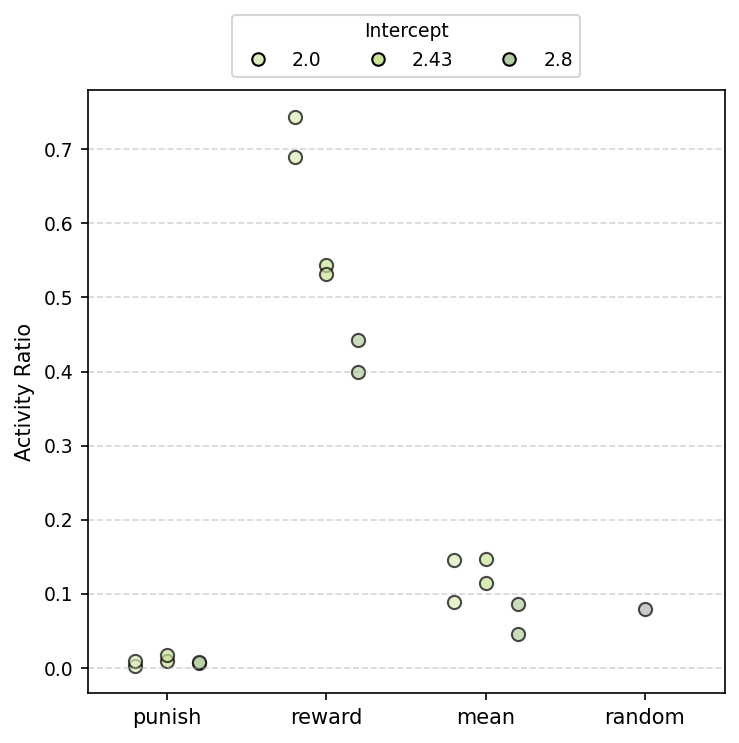

In [194]:
import matplotlib.pyplot as plt
import numpy as np

# Example variables (replace with your data)
# list_all[6] has shape (n_seeds, n_methods, n_intercepts)
# colour = method colours
# colour_factor = intercept tones (pastel steps)

fig, ax = plt.subplots(1, 1, figsize=(5,5), dpi=150)

n_methods = len(methods)
n_intercepts = list_all[0].shape[2]

# Width offset to separate intercepts within each method
offset = 0.2

for i in range(n_methods-1):
    for j in range(n_intercepts):
        # X position with small shift for intercept
        x_pos = i + (j - (n_intercepts-1)/2) * offset
        y_values = list_all[7][:, i, j]
        ax.scatter(
            np.full_like(y_values, x_pos),
            y_values,
            color=intercept_colours[j],
            alpha=0.7,
            edgecolor='k',
            s=40
        )
# random stuiff
x_pos = i + 1
y_values = percent_active_random
ax.scatter(
    np.full_like(y_values, x_pos),
    y_values,
    color=[0.7,0.7,0.7],
    alpha=0.7,
    edgecolor='k',
    s=40
)


# Add method labels at integer x positions
ax.set_xticks(range(n_methods))
ax.set_xticklabels(methods, fontsize=10)

# ax.set_xlabel("Method", fontsize=12)
ax.set_ylabel("Activity Ratio", fontsize=10)
# ax.set_title("Gini Coefficient per Method & Intercept", fontsize=13)

# Optional: grid + nicer styling
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_xlim(-0.5, n_methods-0.5)

# Legend for intercepts
from matplotlib.lines import Line2D
intercept_handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=intercept_colours[j],
           markersize=6, label=f"{intercepts[j]}")
    for j in range(n_intercepts)
]
ax.legend(handles=intercept_handles, title="Intercept", loc='upper center', bbox_to_anchor=(0.5, 1.14),
          ncol=3, fancybox=True)

plt.tight_layout()
plt.savefig("percent_active.svg")
plt.show()


Text(0, 0.5, 'Participation Ratio')

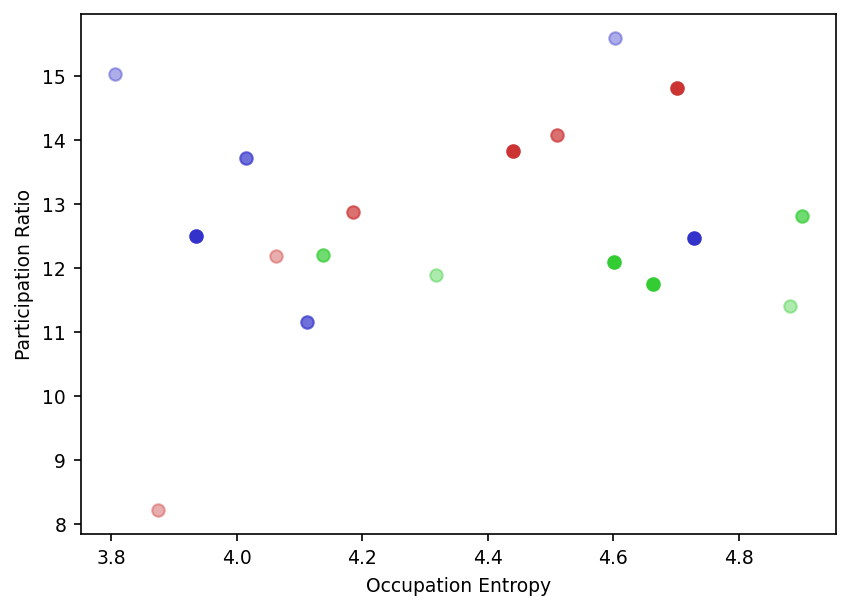

In [156]:
fig,ax=plt.subplots(1,1,figsize=(6.5, 4.5), dpi=150)
for i in range(list_all[0].shape[1]):
    for j in range(list_all[0].shape[2]):
        # print(i,j)
        ax.scatter(list_all[1][:,i,j], list_all[2][:,i,j], color = np.clip(np.append(colour[i],colour_factor[j]),0,1))
ax.set_xlabel("Occupation Entropy")
ax.set_ylabel("Participation Ratio")

In [157]:
participation_ratio_random = np.array([1.7997661069288087])

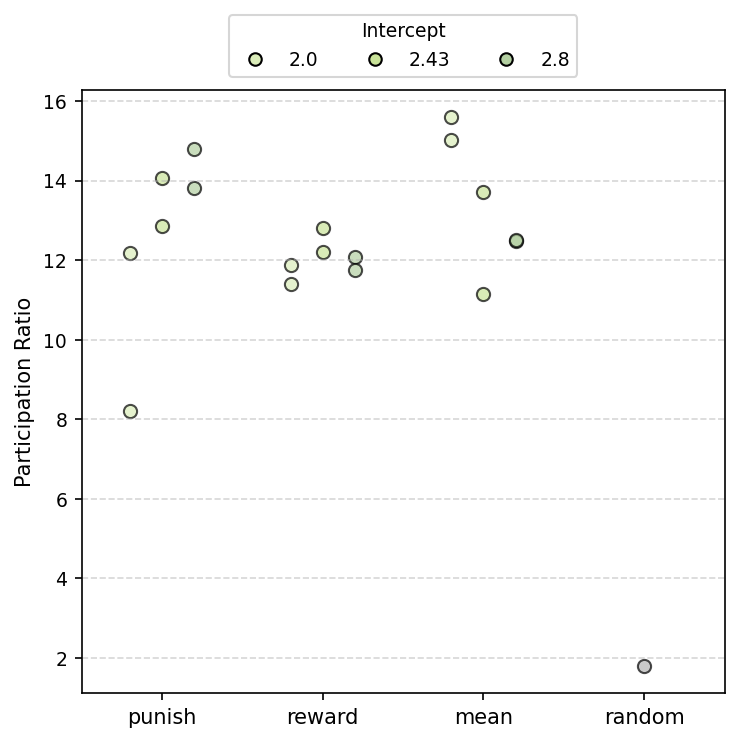

In [158]:
import matplotlib.pyplot as plt
import numpy as np

# Example variables (replace with your data)
# list_all[6] has shape (n_seeds, n_methods, n_intercepts)
# colour = method colours
# colour_factor = intercept tones (pastel steps)

fig, ax = plt.subplots(1, 1, figsize=(5,5), dpi=150)

n_methods = len(methods)
n_intercepts = list_all[0].shape[2]

# Width offset to separate intercepts within each method
offset = 0.2

for i in range(n_methods-1):
    for j in range(n_intercepts):
        # X position with small shift for intercept
        x_pos = i + (j - (n_intercepts-1)/2) * offset
        y_values = list_all[2][:, i, j]
        ax.scatter(
            np.full_like(y_values, x_pos),
            y_values,
            color=intercept_colours[j],
            alpha=0.7,
            edgecolor='k',
            s=40
        )
# random stuiff
x_pos = i + 1
y_values = participation_ratio_random
ax.scatter(
    np.full_like(y_values, x_pos),
    y_values,
    color=[0.7,0.7,0.7],
    alpha=0.7,
    edgecolor='k',
    s=40
)


# Add method labels at integer x positions
ax.set_xticks(range(n_methods))
ax.set_xticklabels(methods, fontsize=10)

# ax.set_xlabel("Method", fontsize=12)
ax.set_ylabel("Participation Ratio", fontsize=10)
# ax.set_title("Gini Coefficient per Method & Intercept", fontsize=13)

# Optional: grid + nicer styling
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_xlim(-0.5, n_methods-0.5)

# Legend for intercepts
from matplotlib.lines import Line2D
intercept_handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=intercept_colours[j],
           markersize=6, label=f"{intercepts[j]}")
    for j in range(n_intercepts)
]
ax.legend(handles=intercept_handles, title="Intercept", loc='upper center', bbox_to_anchor=(0.5, 1.14),
          ncol=3, fancybox=True)

plt.tight_layout()
plt.savefig("participation_ratio.svg")
plt.show()


Text(0, 0.5, 'GINI coefficient')

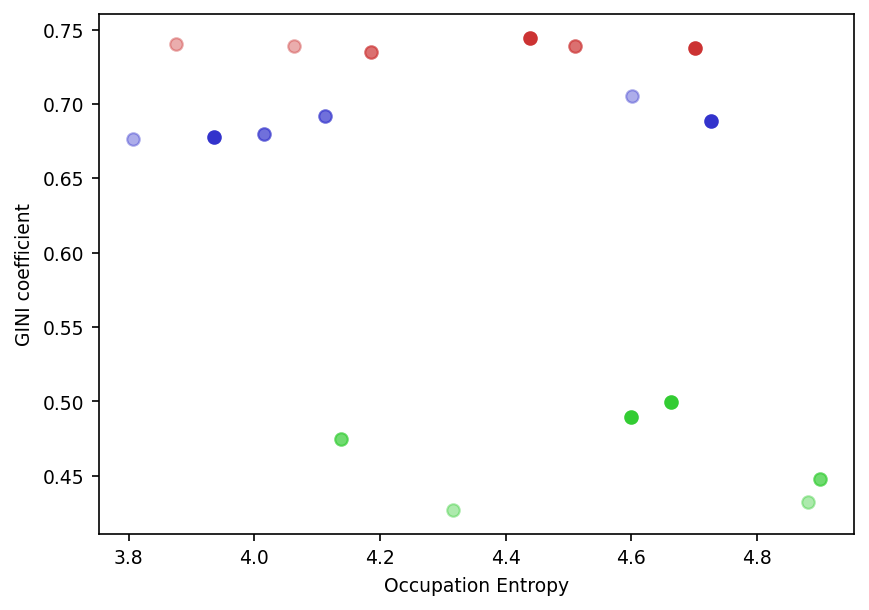

In [159]:
fig,ax=plt.subplots(1,1,figsize=(6.5, 4.5), dpi=150)
for i in range(list_all[0].shape[1]):
    for j in range(list_all[0].shape[2]):
        # print(i,j)
        ax.scatter(list_all[1][:,i,j], list_all[3][:,i,j], color = np.clip(np.append(colour[i],colour_factor[j]),0,1))
ax.set_xlabel("Occupation Entropy")
ax.set_ylabel("GINI coefficient")

Text(0, 0.5, 'PF entropy')

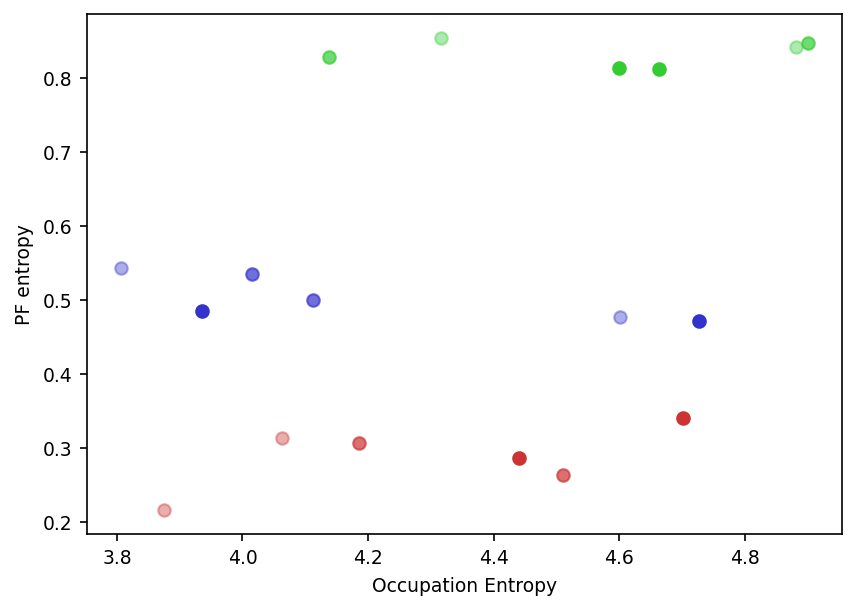

In [160]:
fig,ax=plt.subplots(1,1,figsize=(6.5, 4.5), dpi=150)
for i in range(list_all[0].shape[1]):
    for j in range(list_all[0].shape[2]):
        # print(i,j)
        ax.scatter(list_all[1][:,i,j], list_all[4][:,i,j], color = np.clip(np.append(colour[i],colour_factor[j]),0,1))
ax.set_xlabel("Occupation Entropy")
ax.set_ylabel("PF entropy")

Text(0, 0.5, '19 GINI over sum')

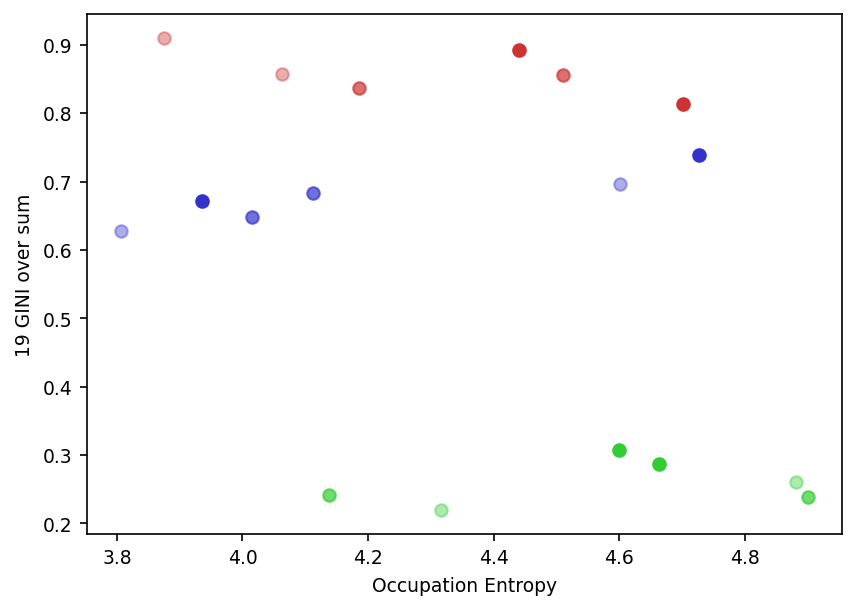

In [161]:
fig,ax=plt.subplots(1,1,figsize=(6.5, 4.5), dpi=150)
for i in range(list_all[0].shape[1]):
    for j in range(list_all[0].shape[2]):
        # print(i,j)
        ax.scatter(list_all[1][:,i,j], list_all[5][:,i,j], color = np.clip(np.append(colour[i],colour_factor[j]),0,1))
ax.set_xlabel("Occupation Entropy")
ax.set_ylabel("19 GINI over sum")

Text(0, 0.5, '4 GINI over sum')

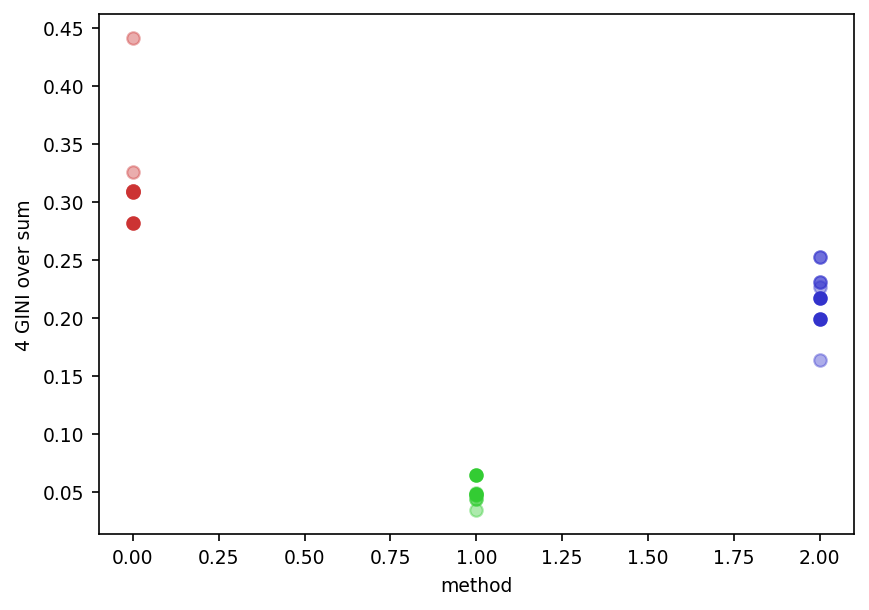

In [162]:
fig,ax=plt.subplots(1,1,figsize=(6.5, 4.5), dpi=150)
for i in range(list_all[0].shape[1]):
    for j in range(list_all[0].shape[2]):
        # print(i,j)
        ax.scatter(np.ones_like(list_all[6][:,i,j])*i, list_all[6][:,i,j], color = np.clip(np.append(colour[i],colour_factor[j]),0,1))
ax.set_xlabel("method")
ax.set_ylabel("4 GINI over sum")

In [163]:
# Example setup (replace with your real data)
# traj_entropy = np.random.rand(2, 3, 3, 16)  # (subjects, methods, intercepts, trials)
intercept_colours = np.array([
    [0.86, 0.93, 0.73],       # lighter sage
    [0.79, 0.89, 0.60],   # base sage (#A1C698)
    [0.70, 0.81, 0.63]    # darker sage
])

methods = ["punish", "reward", "mean", "random"]
intercepts = [2.0, 2.43, 2.8]

In [164]:
gini_over_sum_random = np.array([0.6144651840993249])

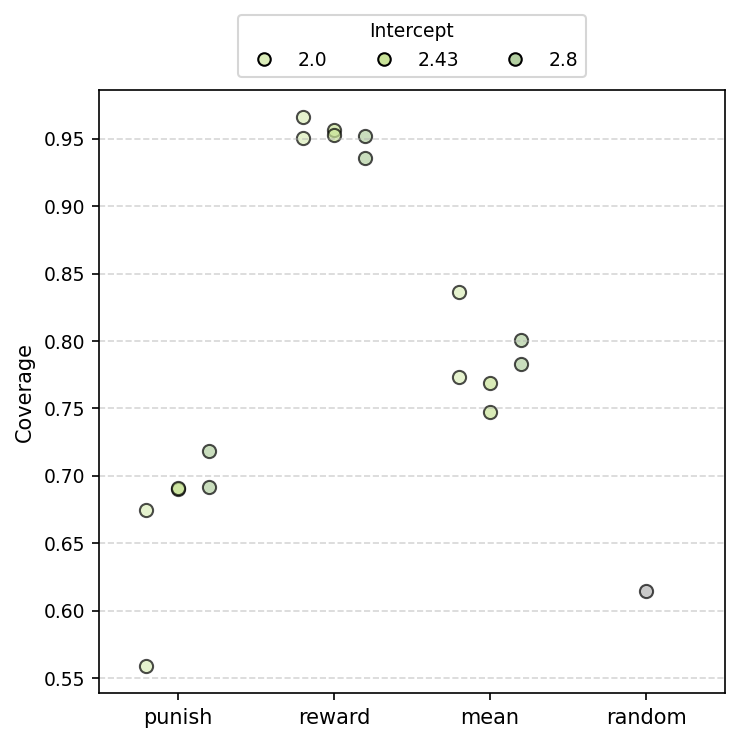

In [199]:
import matplotlib.pyplot as plt
import numpy as np

# Example variables (replace with your data)
# list_all[6] has shape (n_seeds, n_methods, n_intercepts)
# colour = method colours
# colour_factor = intercept tones (pastel steps)

fig, ax = plt.subplots(1, 1, figsize=(5,5), dpi=150)

n_methods = len(methods)
n_intercepts = list_all[0].shape[2]

# Width offset to separate intercepts within each method
offset = 0.2

for i in range(n_methods-1):
    for j in range(n_intercepts):
        # X position with small shift for intercept
        x_pos = i + (j - (n_intercepts-1)/2) * offset
        y_values = 1-list_all[6][:, i, j]
        ax.scatter(
            np.full_like(y_values, x_pos),
            y_values,
            color=intercept_colours[j],
            alpha=0.7,
            edgecolor='k',
            s=40
        )
## random stuiff
x_pos = i + 1
y_values = gini_over_sum_random
ax.scatter(
    np.full_like(y_values, x_pos),
    y_values,
    color=[0.7,0.7,0.7],
    alpha=0.7,
    edgecolor='k',
    s=40
)


# Add method labels at integer x positions
ax.set_xticks(range(n_methods))
ax.set_xticklabels(methods, fontsize=10)

# ax.set_xlabel("Method", fontsize=12)
ax.set_ylabel("Coverage", fontsize=10)
# ax.set_title("Gini Coefficient per Method & Intercept", fontsize=13)

# Optional: grid + nicer styling
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_xlim(-0.5, n_methods-0.5)

# Legend for intercepts
from matplotlib.lines import Line2D
intercept_handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=intercept_colours[j],
           markersize=6, label=f"{intercepts[j]}")
    for j in range(n_intercepts)
]
ax.legend(handles=intercept_handles, title="Intercept", loc='upper center', bbox_to_anchor=(0.5, 1.14),
          ncol=3, fancybox=True)

plt.tight_layout()
plt.savefig("coverage.svg")
plt.show()


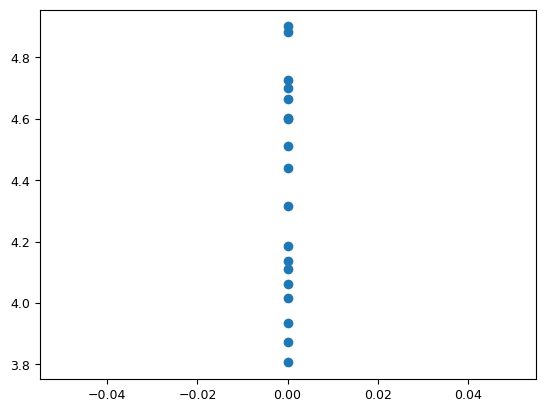

In [166]:
plt.scatter(np.zeros_like(trajectory_entropy) ,trajectory_entropy)

### PF analysis individual

In [167]:
gini_per_neuron = np.array([[       np.nan, 0.75900277, 0.72995153, 0.72565037,        np.nan,
       0.74325524, 0.75285737,        np.nan,        np.nan, 0.75342926,
              np.nan, 0.71824478, 0.75900277, 0.73703165, 0.75419223,
       0.7137164 ], [0.75563131, 0.7588853 , 0.7283504 , 0.722502  , 0.75759275,
       0.758324  , 0.6893721 , 0.7573111 , 0.75900277, 0.75156723,
       0.75900277, 0.74379742, 0.72574505,        np.nan, 0.70826076,
       0.71179411], [       np.nan, 0.75348838, 0.73051805, 0.72684668, 0.71626993,
       0.746679  , 0.75536558, 0.75013373, 0.74901457, 0.75083764,
       0.75278664, 0.74605669, 0.75900277, 0.75253493, 0.72485659,
       0.75059252], [0.4539688 , 0.39294051, 0.45772278, 0.42684355, 0.38990013,
       0.39987694, 0.71608999, 0.46610979, 0.36694934, 0.28406352,
       0.41359039, 0.42006726, 0.42741228, 0.49323   , 0.45042713,
       0.3623956 ], [0.45816581, 0.41700346, 0.5073241 , 0.40940564, 0.41052365,
       0.44445405, 0.43155909, 0.51473181, 0.43242017, 0.421478  ,
       0.4428115 , 0.50904004, 0.39542106, 0.47675528, 0.48532939,
       0.40625268], [0.5676092 , 0.49223898, 0.55696344, 0.44326756, 0.44005201,
       0.4378255 , 0.48694162, 0.54199594, 0.69910931, 0.4121331 ,
       0.44891742, 0.34829332, 0.46811304, 0.54238006, 0.51711067,
       0.425625  ], [0.71890457, 0.69230213, 0.71965796, 0.54726766, 0.58362098,
       0.71093967, 0.73704281, 0.71780176, 0.68881409, 0.72211153,
       0.64560076, 0.70370655, 0.71821039, 0.63803075, 0.58544596,
       0.6979284 ], [0.72991135, 0.67544332, 0.74076759, 0.72457592, 0.73314904,
       0.57589894, 0.74412298, 0.61843327, 0.60526526, 0.65462002,
       0.6978175 , 0.71044104, 0.69389342, 0.64935202, 0.74733728,
       0.57507062], [0.66996886, 0.72206407, 0.74530529, 0.70294575, 0.74556771,
       0.74773726, 0.75067363, 0.74983414, 0.74889176, 0.39432167,
       0.39443135, 0.74810908, 0.7260677 , 0.72749899, 0.70969783,
       0.73801751], [0.74326831, 0.74094867, 0.7248633 ,        np.nan, 0.74407474,
       0.75900277, 0.71845684, 0.73352615,        np.nan, 0.73169373,
       0.74623918, 0.73013483, 0.71827407, 0.75118087, 0.75365482,
       0.7514683 ], [0.66088304, 0.75557745, 0.75254664, 0.74004239, 0.73195747,
       0.75454106, 0.73762472,        np.nan, 0.74144396,        np.nan,
       0.75133247, 0.74808913, 0.72418644, 0.72026412, 0.73100817,
              np.nan], [0.71007202, 0.75016522, 0.73623485, 0.75900277, 0.74888277,
       0.74775422, 0.74784386, 0.73175896, 0.73329676, 0.75608175,
       0.71224113, 0.72004416, 0.74633488,        np.nan, 0.74512628,
       0.71503986], [0.36147903, 0.286522  , 0.47330647, 0.51916875, 0.34130794,
       0.39426346, 0.49292143, 0.46505343, 0.35186641, 0.48505535,
       0.49500518, 0.34274402, 0.37597547, 0.52190495, 0.50543863,
       0.41543791], [0.44771591, 0.38619901, 0.54299085, 0.48247382, 0.40084321,
       0.49381105, 0.51319775, 0.51527371, 0.39580908, 0.53495498,
       0.43456697, 0.48354841, 0.43516011, 0.5340326 , 0.55638787,
       0.44408002], [0.44527821, 0.49972268, 0.44583609, 0.50873034, 0.56620543,
       0.45645997, 0.56741367, 0.48946213, 0.56865063, 0.52445759,
       0.44258679, 0.45983065, 0.59704968, 0.55863193, 0.44495566,
       0.41886649], [0.74894135, 0.72104358, 0.71179825, 0.74302821, 0.74157153,
       0.75108628, 0.72706123, 0.72320869, 0.73709958, 0.72473103,
       0.64633088, 0.74181612, 0.71706672, 0.41368145, 0.73277343,
       0.70710001], [0.64833423, 0.53945669, 0.74726373, 0.74373433, 0.66048817,
       0.74151789, 0.6335157 , 0.75216086, 0.74111475, 0.75133042,
       0.73680849, 0.72834556, 0.74122392, 0.52596832, 0.66386707,
       0.71724374], [0.637619  , 0.69805993, 0.73843697, 0.72050553, 0.73378407,
       0.69233826, 0.68617165,        np.nan, 0.55711938, 0.70564202,
       0.72879337, 0.44934997, 0.72135297, 0.70490131, 0.65714773,
       0.73790162]])

In [168]:
gini_per_neuron = gini_per_neuron.reshape(2,3,3,16)

IndexError: index 3 is out of bounds for axis 0 with size 3

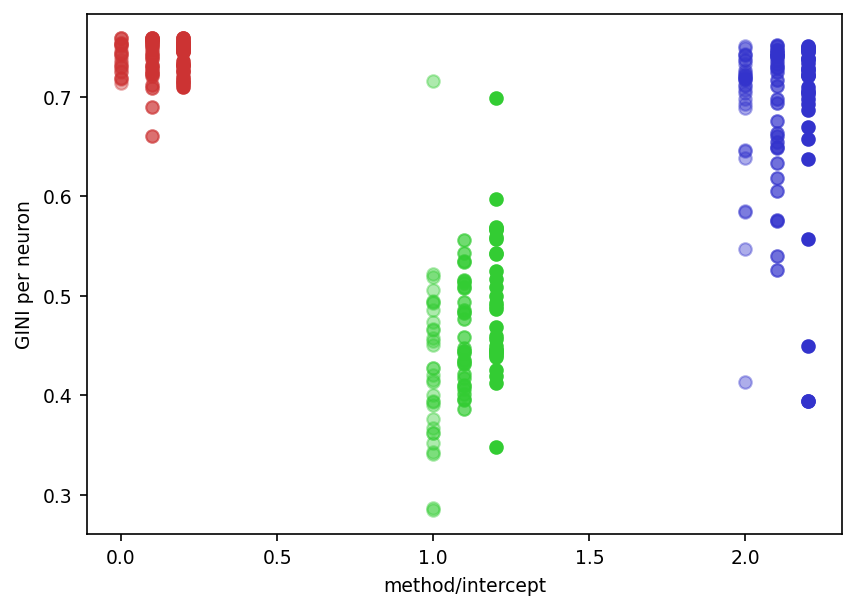

In [170]:
fig,ax=plt.subplots(1,1,figsize=(6.5, 4.5), dpi=150)
for i in range(gini_per_neuron.shape[1]):
    for j in range(gini_per_neuron.shape[2]):
        # print(i,j)
        ax.scatter(np.ones_like(gini_per_neuron[:,i,j,:])*i+0.1*j, gini_per_neuron[:,i,j,:], color = np.clip(np.append(colour[i],colour_factor[j]),0,1))
ax.set_xlabel("method/intercept")
ax.set_ylabel("GINI per neuron")

# --- Create legends ---
# Legend 1: methods (solid colors)
method_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=colour[i],
           markersize=6, label=methods[i])
    for i in range(len(methods))
]

# Legend 2: intercepts (gray with different opacity)
intercept_handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=(0,0,0, colour_factor[j]),
           markersize=6, label=f"intercept={intercepts[j]}")
    for j in range(len(intercepts))
]

# Add legends separately
legend1 = ax.legend(handles=method_handles, title="Method", loc='lower left')
ax.add_artist(legend1)
ax.legend(handles=intercept_handles, title="Intercept", loc='lower right')

In [171]:
gini_per_neuron_random = np.array([0.        , 0.        , 0.41801217, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.886912  , 0.        , 0.65427443, 0.        ,
       0.        ])

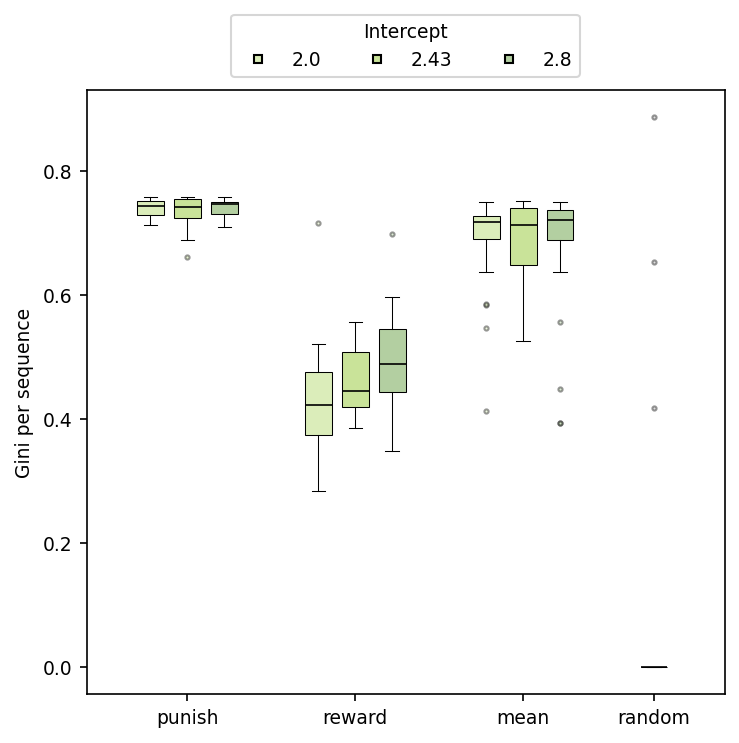

In [172]:
# Example setup (replace with your real data)
# traj_entropy = np.random.rand(2, 3, 3, 16)  # (subjects, methods, intercepts, trials)
intercept_colours = np.array([
    [0.86, 0.93, 0.73],       # lighter sage
    [0.79, 0.89, 0.60],   # base sage (#A1C698)
    [0.70, 0.81, 0.63]    # darker sage
])

methods = ["punish", "reward", "mean", "random"]
intercepts = [2.0, 2.43, 2.8]

fig, ax = plt.subplots(1, 1, figsize=(5,5), dpi=150)

# --- Plot boxplots ---
positions = []
data = []
colors = []

for i in range(gini_per_neuron.shape[1]):  # methods
    for j in range(gini_per_neuron.shape[2]):  # intercepts
        pos = i*0.5 + 0.11 * j - 0.11
        positions.append(pos)
        tmp_data = gini_per_neuron[:, i, j, :].flatten()
        data.append(tmp_data[~np.isnan(tmp_data)])
        colors.append(intercept_colours[j])


# -----------------------------
# Add the "random" method box
# -----------------------------
i = 3  # 4th method index
p = i * 0.5 - 0.11  # place it at regular method spacing
positions.append(p)

# flatten the random array (shape n)
data.append(gini_per_neuron_random.flatten())

# choose color for this method
colors.append([0.7, 0.7, 0.7])

# Create boxplots one by one for custom colors
for d, p, c in zip(data, positions, colors):
    # print(d.shape)
    # print(p)
    bp = ax.boxplot(d, positions=[p], widths=0.08,
                    patch_artist=True, boxprops=dict(facecolor=c, color='k', linewidth=0.5),
                    medianprops=dict(color='k', linewidth=0.8),
                    whiskerprops=dict(color='k', linewidth=0.5),
                    capprops=dict(color='k', linewidth=0.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, markerfacecolor=c))

# ax.set_xlabel("method/intercept")
ax.set_ylabel("Gini per sequence")
ax.set_xlim(-0.3,1.6)

# Adjust x-ticks for clarity
xrange = np.arange(len(methods)) * 0.5
xrange[-1] -= 0.11
ax.set_xticks(xrange)
ax.set_xticklabels(methods)

# --- Create legends ---
# Legend 1: methods (solid colors)
# method_handles = [
#     Line2D([0], [0], marker='s', color='none', markerfacecolor=colour[i],
#            markersize=8, label=methods[i])
#     for i in range(len(methods))
# ]

# Legend 2: intercepts (grayscale with opacity)
intercept_handles = [
    Line2D([0], [0], marker='s', color='none',
           markerfacecolor=(intercept_colours[j]),
           markersize=4, label=f"{intercepts[j]}")
    for j in range(len(intercepts))
]

# Add legends separately
# legend1 = ax.legend(handles=method_handles, title="Method", loc='lower left')
# ax.add_artist(legend1)
ax.legend(handles=intercept_handles, title="Intercept", loc='upper center', bbox_to_anchor=(0.5, 1.14),
          ncol=3, fancybox=True)

plt.tight_layout()
plt.savefig("gini_per_sequence.svg")
plt.show()




In [173]:
import matplotlib.colors
colours = np.array(["#ffae00", "#9e0dff", "#00ffbf"])

for i in range(len(colours)):
    print(matplotlib.colors.to_rgb(colours[i]))

(1.0, 0.6823529411764706, 0.0)
(0.6196078431372549, 0.050980392156862744, 1.0)
(0.0, 1.0, 0.7490196078431373)


In [174]:
pf_netropy_per_neuron = np.array([[ 0.        , -0.        ,  0.45642871,  0.47938145,  0.        ,
        0.36873715,  0.24576116,  0.        ,  0.        ,  0.23094188,
        0.        ,  0.51353698, -0.        ,  0.40763735,  0.21157206,
        0.53133067], [ 0.16644035,  0.01743765,  0.46373187,  0.49404159,  0.10560001,
        0.06315503,  0.59431163,  0.10448967, -0.        ,  0.26840474,
       -0.        ,  0.36059543,  0.4854448 ,  0.        ,  0.54446458,
        0.53696597], [ 0.        ,  0.22755738,  0.45436713,  0.47692056,  0.52297277,
        0.3300913 ,  0.17505979,  0.26580217,  0.30410176,  0.27121918,
        0.231824  ,  0.32915642, -0.        ,  0.2448996 ,  0.48199354,
        0.27382191], [0.84382718, 0.87465092, 0.84631417, 0.86192824, 0.87418778,
       0.87062003, 0.51844348, 0.84206386, 0.88351247, 0.91402561,
       0.86514095, 0.86141714, 0.86241814, 0.8202405 , 0.85017267,
       0.88743097], [0.84318444, 0.86101749, 0.81594283, 0.86609667, 0.86521754,
       0.85017589, 0.85750846, 0.80998865, 0.85496487, 0.86091174,
       0.84956494, 0.81456227, 0.87471569, 0.82993858, 0.82854156,
       0.86657347], [0.77040974, 0.82075671, 0.77757467, 0.85070221, 0.84983421,
       0.85227037, 0.82608107, 0.7903158 , 0.57793681, 0.8642728 ,
       0.84536457, 0.89299516, 0.83687109, 0.78691975, 0.80783407,
       0.85697106], [0.4543148 , 0.56542586, 0.45662217, 0.77311726, 0.73378369,
       0.49060931, 0.29948629, 0.38706962, 0.56665331, 0.43543649,
       0.66222906, 0.51312332, 0.4596482 , 0.618397  , 0.73382234,
       0.5476909 ], [0.36408708, 0.61868453, 0.32670429, 0.46224511, 0.40733609,
       0.75427925, 0.2973629 , 0.70886431, 0.7250382 , 0.65083945,
       0.53861694, 0.49612311, 0.57273451, 0.65301345, 0.234694  ,
       0.75398306], [0.63863758, 0.49280069, 0.34866426, 0.55149744, 0.34463511,
       0.32109782, 0.27341989, 0.29513466, 0.30756138, 0.87368171,
       0.8737309 , 0.31942303, 0.47514746, 0.47530691, 0.53965847,
       0.41170431], [ 0.36621817,  0.39055969,  0.47497768,  0.        ,  0.35839162,
       -0.        ,  0.50946558,  0.42370325,  0.        ,  0.45189912,
        0.33250404,  0.45607722,  0.51229921,  0.25810661,  0.2214681 ,
        0.25476173], [0.65876097, 0.16644085, 0.24264139, 0.38923122, 0.44882581,
       0.18085469, 0.41436509, 0.        , 0.38401841, 0.        ,
       0.26572027, 0.31693215, 0.48562238, 0.49973869, 0.45243523,
       0.        ], [ 0.5394802 ,  0.28719934,  0.42000323, -0.        ,  0.30369568,
        0.3185395 ,  0.31413715,  0.44152524,  0.42744578,  0.15488415,
        0.53558827,  0.50046106,  0.33274532,  0.        ,  0.34658644,
        0.52090301], [0.88472018, 0.91603555, 0.83297017, 0.80904869, 0.89684728,
       0.86801028, 0.81868009, 0.83710423, 0.88734317, 0.82871211,
       0.82442531, 0.89635687, 0.8798525 , 0.80441945, 0.81529046,
       0.86265124], [0.84574627, 0.87453153, 0.78729962, 0.82762878, 0.86810359,
       0.82494576, 0.81242599, 0.80653197, 0.86953948, 0.7960984 ,
       0.84801242, 0.82713553, 0.85302923, 0.78995956, 0.77894807,
       0.84847922], [0.84800148, 0.81859092, 0.84766326, 0.81214217, 0.77140347,
       0.84218286, 0.77045462, 0.82140534, 0.76120022, 0.80298042,
       0.84846424, 0.83706807, 0.74160987, 0.76820968, 0.84872145,
       0.85764221], [0.29493712, 0.49758836, 0.53697673, 0.3627487 , 0.37614475,
       0.27237894, 0.47178859, 0.49354353, 0.41198726, 0.48497163,
       0.67385014, 0.38182251, 0.52178571, 0.86425066, 0.43439414,
       0.54785178], [0.68121708, 0.78581572, 0.32618657, 0.36484388, 0.63804043,
       0.38196191, 0.69238764, 0.25263656, 0.38567545, 0.26880329,
       0.42210456, 0.47001996, 0.35150964, 0.79932127, 0.65047323,
       0.51608785], [0.67412365, 0.49603862, 0.29237693, 0.44719252, 0.33878934,
       0.56380645, 0.56280447, 0.        , 0.76627682, 0.52320529,
       0.39944615, 0.84015475, 0.42771055, 0.48131591, 0.64312975,
       0.30447763]])
pf_netropy_per_neuron = pf_netropy_per_neuron.reshape((2,3,3,16))
pf_netropy_per_neuron.shape

(2, 3, 3, 16)

IndexError: index 3 is out of bounds for axis 0 with size 3

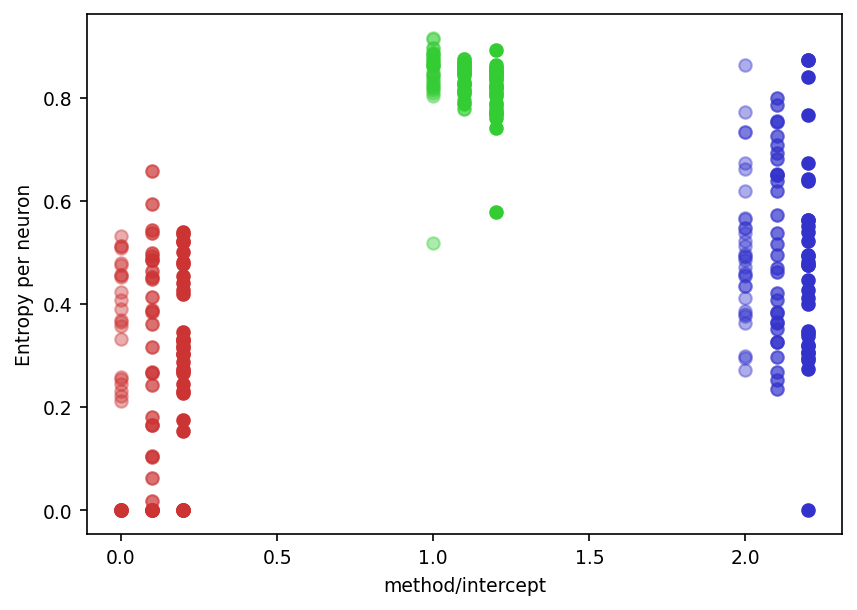

In [175]:
fig,ax=plt.subplots(1,1,figsize=(6.5, 4.5), dpi=150)
for i in range(pf_netropy_per_neuron.shape[1]):
    for j in range(pf_netropy_per_neuron.shape[2]):
        # print(i,j)
        ax.scatter(np.ones_like(pf_netropy_per_neuron[:,i,j,:])*i+0.1*j, pf_netropy_per_neuron[:,i,j,:], color = np.clip(np.append(colour[i],colour_factor[j]),0,1))
ax.set_xlabel("method/intercept")
ax.set_ylabel("Entropy per neuron")

# --- Create legends ---
# Legend 1: methods (solid colors)
method_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=colour[i],
           markersize=6, label=methods[i])
    for i in range(len(methods))
]

# Legend 2: intercepts (gray with different opacity)
intercept_handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=(0,0,0, colour_factor[j]),
           markersize=6, label=f"intercept={intercepts[j]}")
    for j in range(len(intercepts))
]

# Add legends separately
legend1 = ax.legend(handles=method_handles, title="Method", loc='upper left')
ax.add_artist(legend1)
ax.legend(handles=intercept_handles, title="Intercept", loc='lower right')

In [176]:
pf_netropy_per_neuron_random = np.array([0.        , 0.        , 0.8906218 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.27277313, 0.        , 0.71671047, 0.        ,
       0.        ])

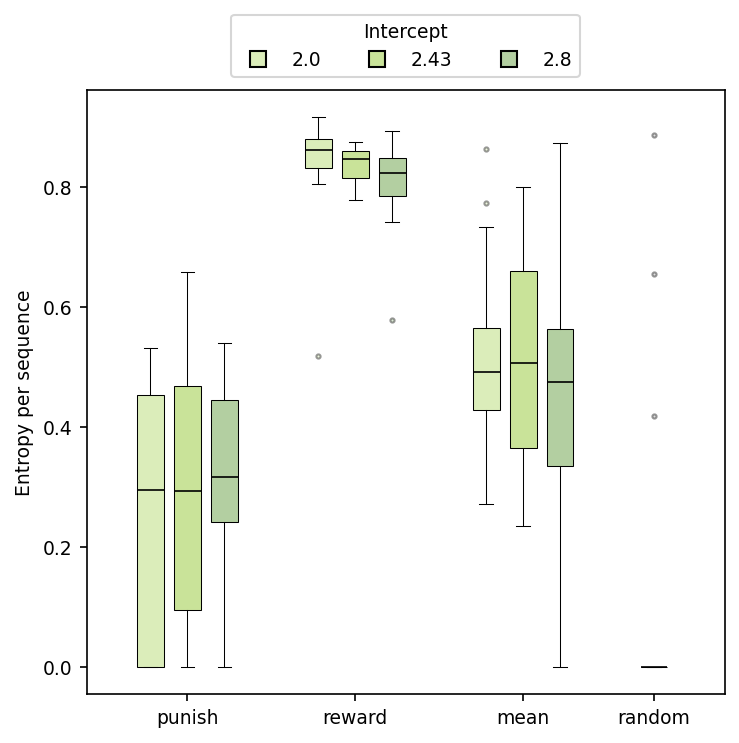

In [177]:

methods = ["punish", "reward", "mean", "random"]
intercepts = [2.0, 2.43, 2.8]

fig, ax = plt.subplots(1, 1, figsize=(5,5), dpi=150)

# --- Plot boxplots ---
positions = []
data = []
colors = []

for i in range(pf_netropy_per_neuron.shape[1]):  # methods
    for j in range(pf_netropy_per_neuron.shape[2]):  # intercepts
        pos = i*0.5 + 0.11 * j - 0.11
        positions.append(pos)
        data.append(pf_netropy_per_neuron[:, i, j, :].flatten())
        colors.append(intercept_colours[j])

# -----------------------------
# Add the "random" method box
# -----------------------------
i = 3  # 4th method index
p = i * 0.5 - 0.11  # place it at regular method spacing
positions.append(p)

# flatten the random array (shape n)
data.append(gini_per_neuron_random.flatten())

# choose color for this method
colors.append([0.7, 0.7, 0.7])

# Create boxplots one by one for custom colors
for d, p, c in zip(data, positions, colors):
    # print(d.shape)
    # print(p)
    bp = ax.boxplot(d, positions=[p], widths=0.08,
                    patch_artist=True, boxprops=dict(facecolor=c, color='k', linewidth=0.5),
                    medianprops=dict(color='k', linewidth=0.8),
                    whiskerprops=dict(color='k', linewidth=0.5),
                    capprops=dict(color='k', linewidth=0.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, markerfacecolor=c))

# ax.set_xlabel("method/intercept")
ax.set_ylabel("Entropy per sequence")
ax.set_xlim(-0.3,1.6)

# Adjust x-ticks for clarity
xrange = np.arange(len(methods)) * 0.5
xrange[-1] -= 0.11
ax.set_xticks(xrange)
ax.set_xticklabels(methods)


# --- Create legends ---
# Legend 1: methods (solid colors)
# method_handles = [
#     Line2D([0], [0], marker='s', color='none', markerfacecolor=colour[i],
#            markersize=8, label=methods[i])
#     for i in range(len(methods))
# ]

# Legend 2: intercepts (grayscale with opacity)
intercept_handles = [
    Line2D([0], [0], marker='s', color='none',
           markerfacecolor=(intercept_colours[j]),
           markersize=8, label=f"{intercepts[j]}")
    for j in range(len(intercepts))
]

# Add legends separately
# legend1 = ax.legend(handles=method_handles, title="Method", loc='lower left')
# ax.add_artist(legend1)
ax.legend(handles=intercept_handles, title="Intercept", loc='upper center', bbox_to_anchor=(0.5, 1.14),
          ncol=3, fancybox=True)

plt.tight_layout()
plt.savefig("entropy_per_sequence.svg")
plt.show()

### traj entropy individual

In [178]:
traj_entropy = np.array([[4.15060842, 4.27724812, 4.3149458 , 4.48354133, 4.06714998,
       3.90160127, 4.3936459 , 4.06045783, 4.14266635, 4.37971294,
       4.41633418, 3.86578001, 3.50170256, 4.14145793, 3.86565941,
       4.15894768, 4.40632224, 3.92105337, 3.87135165, 3.25497796,
       4.31809948, 3.74436922, 3.1887133 , 3.53517468, 2.67248701,
       3.39751778, 4.22041795, 4.35385494, 4.01447258, 3.4706123 ,
       3.94849989, 3.60224792, 3.84850702, 4.50605088, 3.95289574,
       3.25464873, 3.14934366, 3.68903114, 4.14642364, 4.2650617 ,
       3.42709   , 3.92694291, 2.63087163, 3.88535493, 4.25904355,
       3.87442191, 3.08945826, 2.78956641, 3.85907544, 4.2228126 ,
       4.06444271, 4.43388527, 3.70202797, 4.20812527, 4.18959922], [4.45613934, 4.61696102, 4.15437741, 4.36350917, 3.84999352,
       4.82346082, 4.70031949, 4.25857544, 4.84275226, 4.75269494,
       4.76672449, 4.84899578, 4.38589564, 4.20760475, 4.46934264,
       4.67892103, 4.31923647, 4.45324135, 4.40225798, 4.82119351,
       4.83015459, 4.75084801, 4.186047  , 4.78918122, 4.33053463,
       4.66309128, 4.59385859, 4.33617226, 4.83857449, 4.72060644,
       4.71602721, 4.88676775, 4.70806926, 4.14981915, 4.75202698,
       4.62550544, 3.86577238, 3.64467104, 3.60775672, 4.77127424,
       3.44318999, 4.81330161, 4.74534228, 4.08959883, 4.97105149,
       4.95357977, 4.74243325, 4.59683454, 4.73471014, 4.25282774,
       4.73619869, 4.3688344 , 4.31274486, 4.86627941, 4.63375298], [4.19099404, 3.93177494, 4.3731228 , 4.33400456, 3.8885192 ,
       4.57961362, 4.50515231, 5.00318402, 4.69483148, 3.94356909,
       4.51109878, 4.27956455, 4.49181995, 4.48365932, 4.46636305,
       4.5133668 , 4.83359203, 4.72505602, 4.34783138, 4.3974575 ,
       4.31140854, 4.48245209, 4.61151942, 3.92533504, 4.28889153,
       4.78639307, 4.63566194, 4.25382786, 4.52754958, 4.59165408,
       4.88571497, 4.27135028, 4.49480725, 4.61554287, 4.42483544,
       4.56932812, 4.35572062, 4.14214823, 3.90439712, 4.09225426,
       4.33614723, 4.41296888, 4.28326565, 4.72390301, 4.64315229,
       4.05323154, 4.90599297, 4.51263754, 4.38652516, 4.92703271,
       4.45992349, 4.32860425, 4.74148169, 4.3644309 , 4.15198611], [4.81423179, 4.80819433, 4.89047074, 4.94735344, 4.95851788,
       4.83475596, 5.06516451, 5.07803687, 5.09148212, 4.94631312,
       4.75648881, 4.9215934 , 5.02509079, 4.82956303, 4.92956776,
       5.01426988, 4.99371152, 4.96071281, 4.71329247, 5.06324833,
       4.93819966, 4.90323929, 4.56636341, 4.44078975, 4.82585543,
       4.85569494, 4.75244222, 4.79926683, 4.91299663, 4.74430917,
       4.83084069, 4.95114367, 4.83011843, 4.81280723, 5.01057553,
       4.77578138, 4.84325034, 4.99157854, 4.94460164, 4.85936768,
       4.80675733, 4.91658453, 5.05083825, 4.6496465 , 4.83853422,
       4.81834739, 4.93220516, 4.78942556, 4.8883125 , 4.93500159,
       4.76294388, 4.85208831, 5.11872556, 5.02400575, 4.75568757], [5.12103669, 4.84654692, 4.89267575, 5.08624876, 4.92784412,
       5.01437199, 4.95374864, 5.08008668, 4.83369616, 4.98033417,
       4.97496088, 4.76545861, 4.94931836, 5.06154852, 4.93491742,
       4.77573899, 5.00410122, 4.91495665, 4.54853331, 4.92448719,
       4.35400053, 4.89736134, 4.94960567, 4.83003677, 4.7573639 ,
       4.52353613, 4.96716917, 5.11899643, 4.99058932, 5.02034815,
       5.04459523, 5.05044583, 4.9588187 , 4.86568094, 4.8558711 ,
       4.86510807, 4.93413214, 4.90596931, 4.80890465, 4.94432531,
       5.08892291, 4.6678447 , 5.03811454, 4.96316279, 4.82256694,
       5.01637767, 4.93944769, 5.13203951, 4.95248252, 4.84992018,
       4.55736687, 4.97152592, 4.58662206, 4.81120989, 4.58417116], [4.73131821, 4.45952126, 4.00449562, 4.85189773, 4.87219231,
       4.51235023, 4.84493391, 4.22952599, 4.74518499, 4.62957346,
       4.62355496, 4.32233228, 4.17001903, 4.43375132, 4.83456436,
       4.7024882 , 4.83197574, 4.95702641, 4.76677873, 4.41750849,
       4.73878013, 4.6122627 , 4.44974012, 4.06158757, 4.71667567,
       4.45158708, 4.52647186, 4.8264954 , 4.52464235, 4.56683828,
       4.32366652, 5.00273688, 4.62898681, 4.70659881, 4.60282807,
       4.61360844, 4.91277475, 4.79285918, 4.39483495, 4.63345149,
       4.88673671, 4.47386931, 4.67177548, 4.63179261, 4.57779553,
       4.71108694, 4.46459829, 4.65552003, 4.13683577, 4.26136719,
       4.7115017 , 4.50920344, 4.74700033, 4.95342082, 4.70344946], [4.05848365, 4.56419302, 2.51199371, 4.26384078, 4.09300776,
       3.99812629, 3.7776359 , 3.94662742, 3.14330579, 3.3092687 ,
       3.14110195, 4.40284579, 3.6162352 , 3.94246346, 3.81077481,
       3.59367417, 3.12490715, 3.90531004, 3.47004782, 3.36566838,
       3.71769584, 3.01854132, 3.57977707, 3.77879784, 4.11957978,
       3.21656708, 4.36436986, 4.18508962, 2.99350076, 4.39200413,
       3.47774925, 3.71489445, 4.55491203, 4.11124915, 4.12725161,
       4.36276791, 3.45898741, 3.9214867 , 3.18052812, 4.05656361,
       4.15521587, 3.64490811, 4.10461314, 3.13528326, 4.69559146,
       3.27590598, 3.28637441, 3.9924728 , 4.44368625, 4.09252609,
       4.07541115, 4.17297034, 3.63801221, 4.46865623, 3.84150679], [3.86250311, 4.19110227, 4.03589571, 3.89009317, 4.51885441,
       3.7059674 , 3.33880054, 4.19575219, 4.52989366, 4.50800957,
       3.58522443, 4.54506543, 3.77149289, 4.2501022 , 3.94366845,
       3.59851749, 3.35689396, 4.4266421 , 3.78045495, 3.87993689,
       2.97799314, 4.26662501, 3.8372432 , 4.36739243, 3.46489638,
       4.29156853, 4.07242566, 4.10685419, 3.92230151, 3.60562397,
       4.00393882, 4.26428085, 4.48436445, 4.35179211, 3.71228309,
       3.97120785, 4.42764542, 3.95463825, 3.61540682, 3.82824967,
       4.18396713, 4.41154197, 3.9518036 , 3.91955017, 3.92446295,
       4.01490799, 4.25708717, 3.37645863, 4.36277741, 4.03803845,
       4.04849016, 4.37594639, 4.45466469, 4.06226273, 4.35573647], [4.66507847, 4.718105  , 4.69479363, 4.6946274 , 4.93220482,
       4.41544621, 4.37562057, 4.51791871, 4.80678036, 4.71146956,
       4.60176027, 4.99828117, 4.35695301, 4.7551652 , 4.89595327,
       3.88659526, 4.71728633, 4.93526602, 4.66725085, 4.47100898,
       4.49702124, 4.75468568, 4.66841417, 4.69986586, 5.12824223,
       4.78558839, 4.54022321, 4.7052334 , 4.59928783, 4.80886188,
       4.8851513 , 5.00234696, 4.76081665, 4.80349662, 4.71111171,
       4.83018444, 4.91343625, 4.81192011, 4.85246864, 4.78184968,
       4.94616829, 4.95792778, 4.71942796, 5.10273562, 4.65269628,
       4.84739204, 4.92097457, 4.86082117, 4.76741409, 4.53495366,
       4.8818044 , 4.73255925, 4.43692341, 4.57954141, 4.71355344], [4.2874773 , 4.47051936, 3.83189486, 3.42830226, 4.17783103,
       4.41189316, 3.73813276, 4.1078017 , 4.20809765, 4.34328585,
       4.42163212, 4.11194605, 3.88448654, 4.40736532, 3.91321995,
       4.03759966, 3.60401534, 3.85092559, 3.91936176, 4.23610609,
       3.73621674, 3.5918005 , 4.03077957, 4.54820408, 4.43920743,
       4.11730965, 4.22147915, 4.0087568 , 4.84254695, 4.31068288,
       3.49099848, 3.48838186, 4.14513608, 4.20358963, 3.67329379,
       4.10921255, 2.76857704, 3.93989113, 3.94251469, 3.61387373,
       4.35377045, 4.1296007 , 4.26062812, 4.16654641, 4.73572184,
       4.15492138, 4.31645124, 4.38247861, 2.87879726, 4.52285656,
       3.90548499, 4.15388845, 4.34835655, 4.46641814, 4.68807155], [3.81314686, 3.73217418, 4.01142538, 3.62840295, 4.05955372,
       3.66203554, 4.15578638, 4.08959301, 4.17834993, 4.37029814,
       4.36397263, 4.47165677, 3.38982471, 4.01989789, 4.64351178,
       4.12230652, 4.38147454, 4.02041899, 3.87323354, 4.41555867,
       4.35469206, 4.57865147, 4.48012823, 3.97790159, 4.81644   ,
       3.98787931, 3.97764043, 3.99938001, 4.82067656, 4.34352516,
       4.51531558, 4.14535686, 3.68141696, 4.25094315, 4.34541542,
       4.13485758, 4.47929712, 3.90008146, 4.3370126 , 4.37509419,
       3.54924732, 4.04438152, 3.87015673, 4.35577512, 4.41774821,
       4.49772338, 4.40986803, 4.20735599, 4.56074672, 4.71785609,
       4.31784351, 4.13894727, 4.09954697, 3.90521197, 4.45426783], [4.72644548, 4.64398648, 4.66831861, 4.80481516, 4.81492614,
       4.87056462, 4.63549232, 4.55859416, 4.57761935, 4.41668573,
       4.92414909, 4.52549034, 4.78769705, 4.67427013, 4.89563687,
       4.78671774, 4.82608944, 4.59034808, 4.58273976, 4.78376615,
       4.56749509, 4.53203706, 4.6868135 , 4.94482168, 4.8842695 ,
       4.79665117, 4.87272878, 4.19799613, 4.21165667, 4.77144949,
       4.8818815 , 4.56021455, 4.86227382, 4.68178759, 4.73074813,
       4.92327228, 4.73265497, 4.49050257, 4.89927142, 4.78449112,
       4.71495898, 4.92806048, 4.76619417, 4.78610065, 4.64505914,
       4.5168281 , 4.81646554, 4.65331945, 4.82371536, 4.8332177 ,
       4.36013806, 4.86037319, 4.46674638, 4.57695002, 4.581877  ], [4.73411724, 4.85615476, 4.72123288, 3.85905765, 4.32816172,
       4.52406369, 4.48194139, 4.43869014, 4.28195032, 3.46046548,
       4.24551894, 4.43073334, 4.49104268, 4.21256784, 4.0059233 ,
       4.53191188, 4.56614145, 4.20787816, 4.28588029, 4.02435381,
       4.44798558, 4.64346685, 4.58932311, 4.59284285, 4.88028296,
       4.11923421, 4.58121692, 3.53450843, 3.84171803, 4.33151617,
       4.13002667, 4.34115793, 3.91422106, 4.53073626, 4.5204919 ,
       4.16452654, 4.21982604, 3.34880138, 4.72444987, 4.01122847,
       4.80653638, 4.45204778, 3.98181471, 3.81026988, 4.41834801,
       4.54693107, 4.55406734, 4.72316902, 4.12863701, 4.22910505,
       4.02510514, 4.29900031, 4.13606335, 4.83992254, 4.28216797], [4.20983435, 4.24182388, 3.43888421, 4.61323901, 4.11130752,
       4.85779292, 3.70088391, 4.57350892, 4.64546066, 4.11744296,
       2.40813958, 4.46367852, 2.91609454, 3.95962276, 3.91333064,
       4.35318522, 3.08858462, 3.864248  , 3.971993  , 4.24096091,
       4.00553146, 4.39367478, 4.47032133, 4.75406171, 4.23518261,
       3.88698469, 3.75466449, 3.91226971, 4.36346071, 3.32884251,
       4.64605898, 4.43159774, 4.00657852, 3.70362762, 4.20422379,
       4.43264576, 4.74805644, 4.64760851, 3.66392376, 3.89639496,
       4.4973678 , 3.90079391, 4.47205411, 3.56768749, 4.69770685,
       4.60309611, 4.47714979, 4.00825887, 4.17843058, 4.73283831,
       3.69301569, 4.04923526, 4.80791189, 4.59880055, 4.32301889], [4.7787579 , 4.81317613, 4.88160351, 4.48326575, 4.52017701,
       4.68340329, 4.74099552, 4.78351342, 4.49366978, 4.26299465,
       4.6060937 , 4.80622587, 4.71321341, 5.09566621, 4.92988244,
       4.6626781 , 4.67754792, 4.7571979 , 4.65730342, 4.15556648,
       4.37538044, 4.93109743, 4.35957097, 4.73527064, 4.93770587,
       4.69191192, 4.50411978, 4.09327272, 4.18815675, 4.84439116,
       4.50892391, 4.40210013, 4.82593539, 4.22620839, 4.44685937,
       4.52354052, 4.67420765, 4.99898132, 4.8919329 , 4.8606921 ,
       4.89314314, 4.89844917, 4.70985979, 4.40694499, 4.77171854,
       4.89774616, 4.95542527, 4.56770238, 4.9007291 , 4.61902032,
       4.46957833, 4.46052725, 4.65979911, 5.11888914, 4.89630734], [4.70767212, 4.28604121, 4.80119339, 4.2005067 , 4.72878446,
       4.53161675, 4.35556987, 4.78357482, 4.88876964, 4.66105071,
       4.6171326 , 4.98665873, 4.5430616 , 4.68203509, 4.71883909,
       4.77106528, 4.54185914, 3.83159428, 4.88324696, 4.84464592,
       4.62024217, 4.40766117, 4.50306567, 3.6250185 , 4.14155725,
       4.50610355, 4.81134036, 4.68635472, 4.98141362, 4.82692812,
       4.6995786 , 4.30265914, 4.8122456 , 4.67458682, 4.82251416,
       4.45710254, 4.38748835, 4.1384684 , 4.58624767, 4.26490318,
       4.81539655, 4.65380514, 5.00531479, 4.92475999, 4.17314612,
       4.9213591 , 4.499298  , 4.63389226, 4.74268512, 4.42455446,
       4.48733124, 4.74278115, 5.07065494, 4.78687028, 4.88119021], [3.04153102, 4.5810466 , 4.37954704, 4.35245517, 3.24180609,
       4.43907146, 4.43316666, 3.57545942, 4.22751221, 3.79254826,
       3.93149496, 3.74973907, 4.15877162, 4.16364554, 3.99394716,
       3.99019917, 4.32601092, 4.30030033, 3.05723468, 3.63577041,
       3.64168285, 4.81083007, 4.51037537, 4.19406772, 4.14582529,
       4.11732586, 3.97650054, 4.22324058, 3.27911492, 4.49002609,
       4.57891178, 3.43906388, 4.07125328, 4.08819164, 4.29016444,
       4.50234562, 4.27382224, 4.09633726, 4.35220412, 4.18136062,
       4.38774912, 4.0731563 , 4.46254648, 3.82938313, 4.14883181,
       4.58126927, 4.36198434, 3.73815311, 4.82725104, 3.89049028,
       4.34780581, 4.29681053, 4.19595755, 4.29339635, 4.24020743], [4.16316694, 3.88259532, 4.01781643, 2.90794561, 4.31328443,
       3.28798525, 4.21866016, 3.8908591 , 3.94192926, 3.55483896,
       3.41365997, 4.37418317, 3.68578564, 3.28051804, 4.24298083,
       4.07829681, 3.54683074, 3.59131452, 3.7416638 , 3.49590373,
       4.47496095, 3.44881023, 3.94853083, 4.16193692, 3.97094345,
       4.22557734, 4.37178001, 4.03392074, 3.45829138, 3.23242591,
       4.29749099, 3.62058345, 3.72719817, 4.15870234, 4.48330511,
       3.89894066, 3.88373106, 4.15910311, 4.01140098, 4.27744043,
       4.19891508, 4.21751787, 3.84835127, 3.88551121, 4.2215582 ,
       4.45723504, 4.4291148 , 3.86846117, 4.5673972 , 4.10868724,
       3.24559889, 4.05053742, 3.95837952, 3.97738248, 3.67207573]])

In [179]:
traj_entropy = traj_entropy.reshape((2,3,3,55))

IndexError: index 3 is out of bounds for axis 0 with size 3

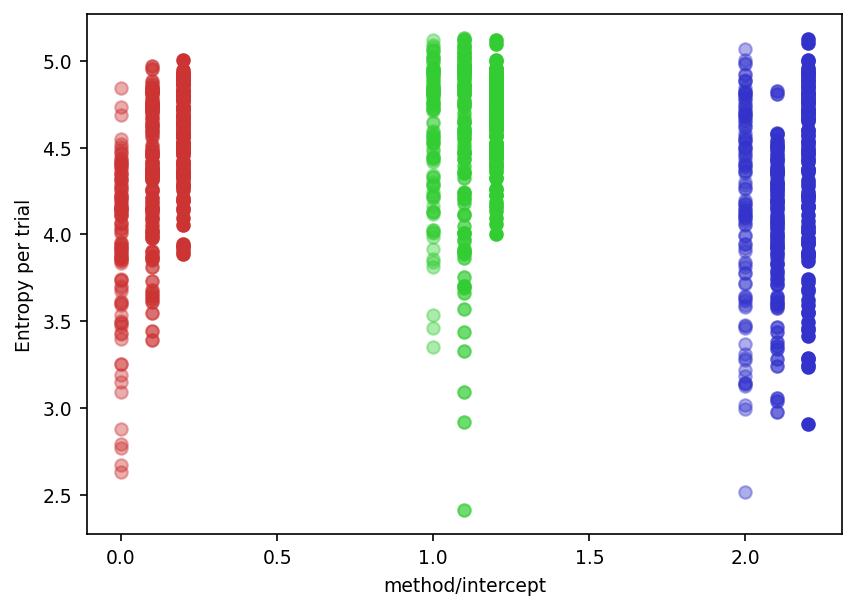

In [180]:
fig,ax=plt.subplots(1,1,figsize=(6.5, 4.5), dpi=150)
for i in range(traj_entropy.shape[1]):
    for j in range(traj_entropy.shape[2]):
        # print(i,j)
        ax.scatter(np.ones_like(traj_entropy[:,i,j,:])*i+0.1*j, traj_entropy[:,i,j,:], color = np.clip(np.append(colour[i],colour_factor[j]),0,1))
ax.set_xlabel("method/intercept")
ax.set_ylabel("Entropy per trial")

# --- Create legends ---
# Legend 1: methods (solid colors)
method_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=colour[i],
           markersize=6, label=methods[i])
    for i in range(len(methods))
]

# Legend 2: intercepts (gray with different opacity)
intercept_handles = [
    Line2D([0], [0], marker='o', color='none',
           markerfacecolor=(0,0,0, colour_factor[j]),
           markersize=6, label=f"intercept={intercepts[j]}")
    for j in range(len(intercepts))
]

# Add legends separately
legend1 = ax.legend(handles=method_handles, title="Method", loc='lower left')
ax.add_artist(legend1)
ax.legend(handles=intercept_handles, title="Intercept", loc='lower right')

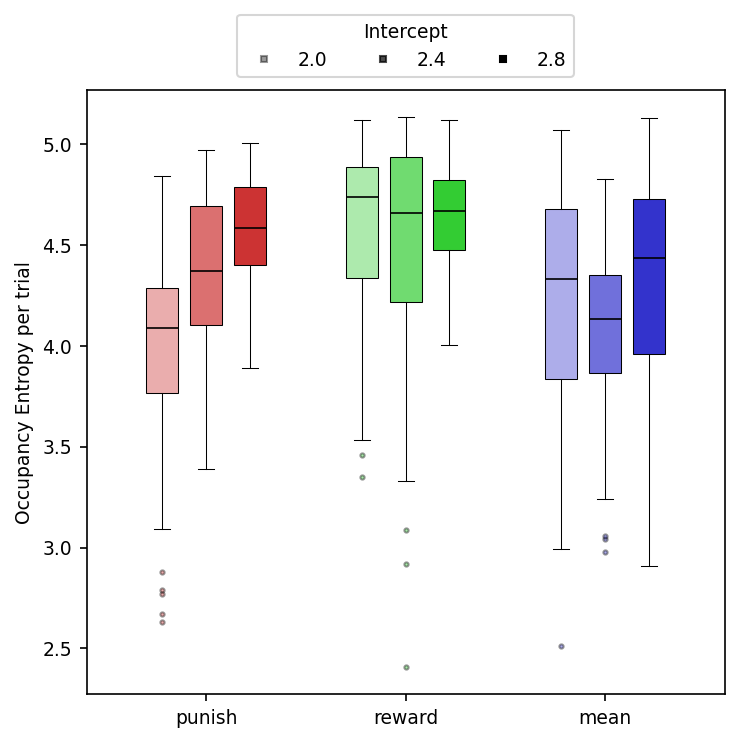

In [181]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Example setup (replace with your real data)
# traj_entropy = np.random.rand(2, 3, 3, 16)  # (subjects, methods, intercepts, trials)
colour = np.array([[0.8, 0.2, 0.2],   # punish: red
                   [0.2, 0.8, 0.2],   # reward: green
                   [0.2, 0.2, 0.8]])  # mean: blue
colour_factor = np.array([0.4, 0.7, 1.0])
methods = ["punish", "reward", "mean"]
intercepts = [2.0, 2.4, 2.8]

fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=150)

# --- Plot boxplots ---
positions = []
data = []
colors = []

for i in range(traj_entropy.shape[1]):  # methods
    for j in range(traj_entropy.shape[2]):  # intercepts
        pos = i*0.5 + 0.11 * j - 0.11
        positions.append(pos)
        data.append(traj_entropy[:, i, j, :].flatten())
        colors.append(np.clip(np.append(colour[i], colour_factor[j]), 0, 1))

# Create boxplots one by one for custom colors
for d, p, c in zip(data, positions, colors):
    bp = ax.boxplot(d, positions=[p], widths=0.08,
                    patch_artist=True, boxprops=dict(facecolor=c, color='k', linewidth=0.5),
                    medianprops=dict(color='k', linewidth=0.8),
                    whiskerprops=dict(color='k', linewidth=0.5),
                    capprops=dict(color='k', linewidth=0.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, markerfacecolor=c))

# ax.set_xlabel("method/intercept")
ax.set_ylabel("Occupancy Entropy per trial")

ax.set_xlim(-0.3,1.3)

# Adjust x-ticks for clarity
ax.set_xticks(np.arange(len(methods))*0.5)
ax.set_xticklabels(methods)

# --- Create legends ---
# Legend 1: methods (solid colors)
# method_handles = [
#     Line2D([0], [0], marker='s', color='none', markerfacecolor=colour[i],
#            markersize=8, label=methods[i])
#     for i in range(len(methods))
# ]

# Legend 2: intercepts (grayscale with opacity)
intercept_handles = [
    Line2D([0], [0], marker='s', color='none',
           markerfacecolor=(0, 0, 0, colour_factor[j]),
           markersize=3, label=f"{intercepts[j]}")
    for j in range(len(intercepts))
]

# Add legends separately
# legend1 = ax.legend(handles=method_handles, title="Method", loc='lower left')
# ax.add_artist(legend1)
ax.legend(handles=intercept_handles, title="Intercept", loc='upper center', bbox_to_anchor=(0.5, 1.14),
          ncol=3, fancybox=True)

plt.tight_layout()
plt.show()


### traj entropy other binning

In [182]:
traj_entropy_6 =  np.array([[2.79668875, 3.02733259, 2.85335904, 3.14190452, 2.76868112,
       2.73204541, 2.98637247, 2.92339945, 2.85467172, 3.11774906,
       3.02185327, 2.59030788, 2.13464367, 2.80527154, 2.68480143,
       2.76569915, 2.97997421, 2.73491776, 2.63035348, 2.32061184,
       3.01550144, 2.66791071, 1.94638524, 2.34051378, 1.58878514,
       2.22050862, 3.06687612, 3.04521516, 2.68732783, 2.12093765,
       2.629375  , 2.27016736, 2.81715766, 3.13099216, 2.8069044 ,
       2.21312397, 2.01648168, 2.47513582, 2.93161268, 2.87562853,
       2.45396889, 2.674178  , 1.61214415, 2.52299432, 3.07949854,
       2.79913791, 1.95035386, 1.5928791 , 2.64408826, 2.91393614,
       2.66870787, 3.07768875, 2.40934129, 2.94028971, 2.85128614], [2.91097556, 3.1616884 , 2.53357368, 2.86679313, 2.5821222 ,
       3.22428077, 3.26721976, 2.75265312, 3.3761699 , 3.15239051,
       3.28029244, 3.29319694, 2.91890582, 2.63947167, 2.88772197,
       3.22435785, 3.06041621, 3.13482547, 3.04325534, 3.27563986,
       3.22602817, 3.25715802, 2.75878533, 3.19605047, 2.57096916,
       3.07378146, 2.99799929, 2.91336045, 3.32508662, 3.13799486,
       3.1657694 , 3.30395396, 3.18642619, 2.88161653, 3.32331249,
       3.22001957, 2.53636129, 2.34356168, 2.03150726, 3.28635876,
       2.31617985, 3.17396702, 3.16171025, 2.618622  , 3.31456927,
       3.26308102, 3.05552255, 3.12603757, 3.32023359, 2.6003771 ,
       3.2046007 , 2.78278468, 2.81649707, 3.14911637, 3.02730775], [2.9238187 , 2.84201172, 2.96663964, 2.94003142, 2.62717989,
       3.16053381, 3.13613841, 3.36903158, 3.22906122, 2.77907557,
       3.08012011, 3.00575677, 3.08782851, 2.95456216, 3.01946526,
       2.9347914 , 3.28646653, 3.28036014, 3.04972777, 3.04193608,
       3.00116872, 3.0683341 , 3.13438401, 2.56537531, 2.81206254,
       3.24765963, 3.12187817, 3.01168856, 3.04366634, 3.13169366,
       3.32834092, 2.87163261, 3.08303635, 3.23841416, 2.97460237,
       3.06031364, 2.93475809, 2.84752874, 2.6475645 , 2.72275728,
       3.0807752 , 3.03572621, 2.95346871, 3.27123429, 3.13084936,
       2.83008697, 3.28422875, 3.10922144, 2.8053164 , 3.34298372,
       3.08212131, 3.03540334, 3.29955684, 2.9126979 , 2.8923701 ], [3.05589498, 3.09054386, 3.17599665, 3.31158497, 3.20552657,
       3.10395016, 3.31373302, 3.43757966, 3.3899539 , 3.25933426,
       3.00705678, 3.23547125, 3.34253835, 3.0870758 , 3.27160294,
       3.41025893, 3.33984687, 3.17587687, 2.98139172, 3.36894246,
       3.31568348, 3.19648669, 2.9165676 , 2.56189859, 3.16692089,
       3.22769695, 3.01044766, 3.03975565, 3.30041244, 3.0452125 ,
       3.14663279, 3.26802687, 3.35184335, 3.18700865, 3.23504047,
       3.19870932, 3.13074034, 3.30213397, 3.31071176, 3.14860286,
       3.10879077, 3.16784404, 3.35568933, 3.03124593, 3.16766481,
       3.11647229, 3.23670428, 3.16109931, 3.16515811, 3.253415  ,
       3.14734515, 3.1541506 , 3.37752316, 3.42803852, 2.99341543], [3.33861602, 3.18050153, 3.08982943, 3.3976709 , 3.19455067,
       3.24150491, 3.24106039, 3.32962207, 3.08202015, 3.22432227,
       3.28063645, 2.98135768, 3.22370438, 3.22014857, 3.13464179,
       3.05894826, 3.24439795, 3.25749328, 2.8314278 , 3.22921628,
       2.45448368, 3.1664158 , 3.22178136, 3.17239332, 3.05619205,
       2.70738676, 3.18026995, 3.32653825, 3.30871762, 3.26592591,
       3.32356517, 3.28927312, 3.16350358, 3.12590371, 3.17546885,
       3.07410038, 3.12405357, 3.20550103, 3.12415224, 3.14437109,
       3.32096464, 2.87536415, 3.29807414, 3.33578365, 3.12497707,
       3.24672087, 3.28295489, 3.33702285, 3.25851665, 3.04591069,
       2.8089454 , 3.24427339, 2.92528446, 3.11161846, 2.90349584], [2.92722935, 2.54787958, 2.2175987 , 3.01148308, 3.02236542,
       2.60040227, 2.98700728, 2.32232981, 3.02498051, 2.78773862,
       2.86904842, 2.40725802, 2.36434925, 2.47875571, 3.00525614,
       2.84664131, 3.02900958, 3.09542365, 2.89498663, 2.64887014,
       2.94636038, 2.73785209, 2.66589986, 2.14819229, 2.90068252,
       2.70411671, 2.63253401, 3.04787103, 2.62715912, 2.74789554,
       2.35632553, 3.3164219 , 2.89818993, 2.89540147, 2.72656092,
       2.8221455 , 3.16641753, 2.86702967, 2.5511447 , 2.75224055,
       3.14977486, 2.67907366, 2.89430135, 2.90114485, 2.80857022,
       2.98686583, 2.78167057, 2.85395881, 2.2025076 , 2.36749893,
       2.88668963, 2.64965979, 2.97715112, 3.1450028 , 3.05805847], [2.30013042, 2.69190899, 0.48068247, 2.43564531, 2.14818224,
       2.07095843, 2.06496307, 1.96780654, 1.35916951, 1.36840078,
       1.15495142, 2.60224684, 1.75820023, 1.97037449, 1.99970772,
       1.68673922, 1.2074629 , 1.88606181, 1.51004718, 1.43959843,
       1.81895133, 1.17235094, 1.66180667, 2.0513837 , 2.26449482,
       1.3270057 , 2.47458036, 2.33868193, 1.27347901, 2.45247314,
       1.53095345, 1.85521858, 2.81627886, 2.2002251 , 2.15985717,
       2.69206664, 1.52690049, 2.15322708, 1.27998665, 2.15438557,
       2.24089879, 1.76292762, 2.33983651, 1.23566854, 2.89233802,
       1.39641676, 1.3458666 , 2.17733551, 2.7337792 , 2.12044465,
       2.20955095, 2.28921635, 1.61818867, 2.67488741, 2.03543828], [1.91779505, 2.42412182, 2.32423766, 2.04932828, 2.81148865,
       1.9799402 , 1.72396142, 2.46870104, 2.83562714, 2.68613239,
       1.79175893, 2.91339924, 2.2136313 , 2.77055802, 2.41738137,
       1.78349643, 1.80588744, 2.62236737, 1.90349463, 1.89963809,
       1.36270427, 2.51336754, 2.08829244, 2.60793013, 1.90238491,
       2.46634079, 2.26930421, 2.22642062, 2.10690909, 1.7618714 ,
       2.31386398, 2.52969143, 2.5474207 , 2.5625484 , 2.07333275,
       2.22700392, 2.69315176, 2.20019832, 2.00008429, 2.19899651,
       2.42827131, 2.57220242, 2.06482591, 2.25525988, 2.29433903,
       2.49100982, 2.55300437, 1.80898107, 2.59976786, 2.26122864,
       2.15958456, 2.60201422, 2.85848198, 2.30952254, 2.50206583], [3.12607489, 3.12223522, 2.86840194, 2.91152858, 3.15370557,
       2.65003921, 2.66363513, 2.98527986, 3.15103907, 2.93990431,
       2.86365472, 3.18352632, 2.74376262, 2.9189612 , 3.2688896 ,
       1.88845547, 3.07796542, 3.26382493, 2.92086519, 2.78437874,
       2.58426798, 2.88672364, 2.94928951, 2.88580913, 3.38126336,
       3.19269539, 2.7510283 , 3.03351687, 2.89143244, 3.01240347,
       3.18431701, 3.22867085, 3.02570414, 3.10659824, 3.06262099,
       3.14956993, 3.27552372, 3.16399742, 3.05800033, 2.85707505,
       3.20502601, 3.25137101, 2.92678006, 3.32274917, 3.10564911,
       3.15737532, 3.10427489, 3.15097246, 3.08348462, 2.62968058,
       3.24181685, 3.10343775, 2.81521163, 2.84871593, 2.95484767], [2.80524542, 2.99893519, 2.63500422, 2.30336094, 2.84167907,
       2.94298406, 2.43422901, 2.777158  , 2.90246409, 2.95133175,
       2.99583268, 2.80640257, 2.76063558, 2.94976482, 2.81572319,
       2.76689828, 2.44780962, 2.72653546, 2.62796008, 2.92379065,
       2.61756742, 2.2555178 , 2.67161938, 3.17236245, 3.01705092,
       2.81123107, 3.02366648, 2.93327695, 3.27641959, 3.02937646,
       2.18732118, 2.2354146 , 2.87928403, 2.91378898, 2.21347995,
       2.91277432, 1.83289368, 2.60848311, 2.69780645, 2.42385947,
       3.0563992 , 2.82111615, 3.04072941, 2.84058032, 3.2502483 ,
       2.80830838, 3.08589648, 3.05320896, 1.65433787, 2.9028312 ,
       2.38290244, 2.81011324, 3.05633467, 3.09202538, 3.17909293], [2.72437846, 2.50628609, 2.91050501, 2.51604635, 2.8580089 ,
       2.73056103, 2.85501743, 2.80977279, 2.81670894, 3.0231204 ,
       3.02802917, 2.9995702 , 2.07602439, 2.89772851, 3.26642337,
       3.01274595, 3.04406803, 2.97300892, 2.61696723, 3.11580087,
       3.0196732 , 3.20586791, 2.99624201, 2.70903923, 3.27947298,
       2.62325791, 2.63226107, 2.89677873, 3.37728405, 2.99249029,
       3.1027718 , 2.68901519, 2.65850794, 2.84941636, 3.03382601,
       2.85146443, 3.15167652, 2.77084041, 3.05281881, 2.90755249,
       2.31436803, 2.96391697, 2.74417258, 2.97192055, 2.99371428,
       3.14757064, 2.85886675, 2.90318269, 3.13381656, 3.11256345,
       3.0850495 , 2.76946622, 2.90639174, 2.88340212, 3.07653918], [3.02561724, 2.97270832, 3.16613817, 3.12512608, 3.11313497,
       3.15600736, 3.06322228, 2.85508707, 3.0327115 , 2.71922867,
       3.27404675, 2.82289023, 3.09015106, 3.10657208, 3.25732377,
       3.07790968, 3.19593881, 2.92207054, 3.10544241, 3.076314  ,
       3.05614586, 2.9569126 , 2.90288523, 3.29414215, 3.26421112,
       3.24447028, 3.17142946, 2.74780767, 2.57469433, 3.1079783 ,
       2.97212731, 3.11660066, 3.15918687, 3.08467681, 3.08557421,
       3.17554652, 3.03845115, 2.92164327, 3.13793929, 3.25277845,
       2.94939978, 3.30955788, 2.95523676, 3.04447906, 3.10344168,
       2.73900162, 3.07209259, 3.13793872, 3.14332198, 3.22169231,
       2.85101565, 3.21570295, 2.74949398, 3.02599948, 3.01046732], [2.97519   , 3.14847555, 2.90400888, 1.86972337, 2.3844079 ,
       2.68496937, 2.62622241, 2.66691386, 2.40601639, 1.68824442,
       2.44602292, 2.55493878, 2.58986071, 2.19344037, 2.07953083,
       2.73703575, 2.63286755, 2.31099333, 2.38149888, 2.13579362,
       2.48333131, 2.77751445, 2.71054124, 2.60889235, 3.08296331,
       2.22203981, 2.6616306 , 1.72327023, 1.95678464, 2.49673256,
       2.40353866, 2.45019529, 2.06367869, 2.73898168, 2.60969236,
       2.44771004, 2.3440578 , 1.50604846, 2.85726442, 2.2474808 ,
       3.03939515, 2.55747498, 2.05044737, 1.89932568, 2.51424055,
       2.69469203, 2.74929361, 2.93562007, 2.28658842, 2.32410195,
       2.0983462 , 2.3645217 , 2.29054479, 3.07064489, 2.51369996], [2.51397157, 2.56741938, 1.75664632, 2.72997599, 2.26756506,
       2.98602375, 2.06841538, 2.82587976, 2.73469287, 2.28329794,
       1.02794217, 2.60176728, 1.20174376, 2.00403444, 2.12054674,
       2.50337527, 1.43134258, 2.10197154, 2.27153762, 2.43258004,
       2.37375012, 2.47164103, 2.64353695, 3.02822069, 2.38360112,
       2.09630155, 1.96288707, 2.04039041, 2.50446385, 1.6934058 ,
       2.84972958, 2.64807321, 2.30505671, 2.07277805, 2.32611476,
       2.60229995, 2.96167499, 2.77851769, 1.83005634, 1.8990069 ,
       2.7793802 , 2.31660427, 2.55439537, 1.93232377, 2.82665098,
       2.96332745, 2.74343765, 2.35619802, 2.24778233, 2.87774998,
       1.78005793, 2.35667574, 3.07297565, 2.84766144, 2.44315172], [3.04124062, 3.07883214, 3.18028734, 2.53419368, 2.73120229,
       2.91149902, 2.99671371, 2.91593402, 2.78818691, 2.45454603,
       2.76047752, 3.05926212, 2.90703687, 3.31369862, 3.18244034,
       2.86918336, 2.97645984, 3.00143751, 2.89154602, 2.35473666,
       2.6229883 , 3.07929797, 2.53280142, 2.96325346, 3.19469815,
       2.88540137, 2.88188879, 2.39994639, 2.37425333, 3.11923353,
       2.66752202, 2.46223185, 2.99705094, 2.4217918 , 2.56962116,
       2.77302762, 3.02243358, 3.31172086, 3.16870755, 3.20208932,
       3.13773334, 3.08185112, 2.84268269, 2.63014324, 2.98427501,
       3.16359475, 3.19207802, 2.8566255 , 3.10290589, 2.84634793,
       2.58337289, 2.59852491, 3.04201669, 3.39433446, 3.1096445 ], [2.97653775, 2.53352945, 2.94487695, 2.3341793 , 2.89271955,
       2.61975753, 2.53481276, 2.96791028, 3.14272121, 2.84583347,
       2.8753145 , 3.22485131, 2.809121  , 2.90997674, 2.95699879,
       3.03269528, 2.78696056, 2.13387194, 3.1814363 , 3.05655471,
       2.80001345, 2.66136024, 2.79085145, 1.9514673 , 2.40978111,
       2.68577818, 3.11059281, 2.82775609, 3.21945954, 3.13302396,
       3.07306207, 2.45520839, 3.00081786, 2.95153079, 2.98927184,
       2.77180638, 2.58786822, 2.4809894 , 2.75574267, 2.48653978,
       3.08543884, 3.0129885 , 3.27309904, 3.07322087, 2.57091062,
       3.1059413 , 2.6744363 , 2.96011123, 2.8432224 , 2.65024992,
       2.69889651, 2.97352946, 3.35583042, 3.04144986, 3.11304938], [1.39477648, 2.785465  , 2.43785314, 2.44740067, 1.38585488,
       2.75310553, 2.61755202, 1.82354702, 2.34755181, 2.24453113,
       2.2053144 , 1.85661891, 2.32863649, 2.342931  , 2.27210449,
       2.07780374, 2.61037523, 2.55073974, 1.51266788, 1.83167701,
       1.86799481, 3.07158179, 2.69202952, 2.42192256, 2.36402388,
       2.30076481, 2.23690633, 2.42196019, 1.61747475, 2.72000664,
       2.86162968, 1.65729942, 2.2342752 , 2.34347337, 2.43521668,
       2.74430636, 2.48490628, 2.19628055, 2.52594457, 2.35013722,
       2.54967166, 2.19968159, 2.66880394, 2.0357072 , 2.34999772,
       2.82414149, 2.69452003, 2.01014901, 3.06267256, 2.07072817,
       2.65691027, 2.55542615, 2.41487942, 2.54880636, 2.40116357], [2.43802961, 1.88962809, 2.27144036, 0.90020001, 2.38888537,
       1.32243838, 2.34848732, 2.26442427, 1.91461019, 1.58863508,
       1.35874045, 2.5624917 , 1.72355883, 1.26547855, 2.40064765,
       2.22346323, 1.72005912, 1.50443869, 2.15280601, 1.62110376,
       2.67324005, 1.58593341, 2.01090941, 2.19001847, 2.19868872,
       2.35427457, 2.55968655, 2.44605254, 1.50642776, 1.13239384,
       2.44058312, 1.80098585, 1.81885639, 2.40620944, 2.66193329,
       1.96981147, 1.89920215, 2.3391934 , 2.18797737, 2.52021088,
       2.52182173, 2.44475049, 1.91085428, 1.85335827, 2.34422538,
       2.63749124, 2.55464333, 2.11703001, 2.76678559, 2.28685221,
       1.28152753, 2.12852298, 2.3158141 , 2.28320139, 1.91803446]])

In [183]:
traj_entropy_6 = traj_entropy_6.reshape((2,3,3,55))

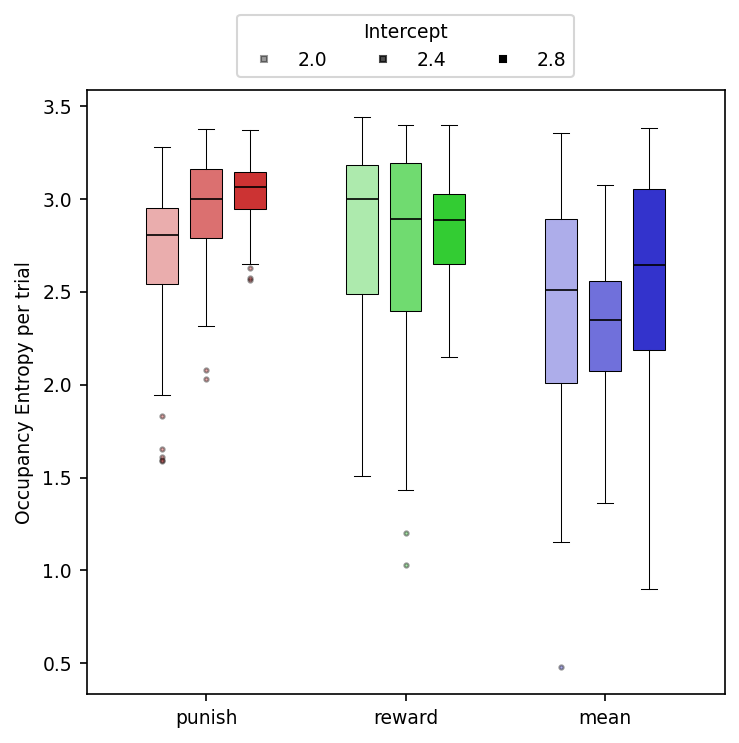

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Example setup (replace with your real data)
# traj_entropy = np.random.rand(2, 3, 3, 16)  # (subjects, methods, intercepts, trials)
colour = np.array([[0.8, 0.2, 0.2],   # punish: red
                   [0.2, 0.8, 0.2],   # reward: green
                   [0.2, 0.2, 0.8]])  # mean: blue
colour_factor = np.array([0.4, 0.7, 1.0])
methods = ["punish", "reward", "mean"]
intercepts = [2.0, 2.4, 2.8]

fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=150)

# --- Plot boxplots ---
positions = []
data = []
colors = []

for i in range(traj_entropy_6.shape[1]):  # methods
    for j in range(traj_entropy_6.shape[2]):  # intercepts
        pos = i*0.5 + 0.11 * j - 0.11
        positions.append(pos)
        data.append(traj_entropy_6[:, i, j, :].flatten())
        colors.append(np.clip(np.append(colour[i], colour_factor[j]), 0, 1))

# Create boxplots one by one for custom colors
for d, p, c in zip(data, positions, colors):
    bp = ax.boxplot(d, positions=[p], widths=0.08,
                    patch_artist=True, boxprops=dict(facecolor=c, color='k', linewidth=0.5),
                    medianprops=dict(color='k', linewidth=0.8),
                    whiskerprops=dict(color='k', linewidth=0.5),
                    capprops=dict(color='k', linewidth=0.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, markerfacecolor=c))

# ax.set_xlabel("method/intercept")
ax.set_ylabel("Occupancy Entropy per trial")

ax.set_xlim(-0.3,1.3)

# Adjust x-ticks for clarity
ax.set_xticks(np.arange(len(methods))*0.5)
ax.set_xticklabels(methods)

# --- Create legends ---
# Legend 1: methods (solid colors)
# method_handles = [
#     Line2D([0], [0], marker='s', color='none', markerfacecolor=colour[i],
#            markersize=8, label=methods[i])
#     for i in range(len(methods))
# ]

# Legend 2: intercepts (grayscale with opacity)
intercept_handles = [
    Line2D([0], [0], marker='s', color='none',
           markerfacecolor=(0, 0, 0, colour_factor[j]),
           markersize=3, label=f"{intercepts[j]}")
    for j in range(len(intercepts))
]

# Add legends separately
# legend1 = ax.legend(handles=method_handles, title="Method", loc='lower left')
# ax.add_artist(legend1)
ax.legend(handles=intercept_handles, title="Intercept", loc='upper center', bbox_to_anchor=(0.5, 1.14),
          ncol=3, fancybox=True)

plt.tight_layout()
plt.show()


In [184]:
traj_entropy_2 =  np.array([[1.18588666, 1.31188855, 1.32181321, 1.24540635, 1.20281857,
       1.34810527, 1.20830595, 1.15879494, 1.21326966, 1.3408779 ,
       1.32853162, 1.13288355, 0.76839407, 1.21880294, 1.33974272,
       1.26724642, 1.16309142, 1.15549194, 1.01565481, 0.80485178,
       1.34872353, 1.15816047, 0.70468669, 1.06020353, 0.79650329,
       1.10190087, 1.31074052, 1.27300387, 1.17689965, 0.69037422,
       1.16010976, 1.04850247, 1.32117249, 1.32046854, 1.27449056,
       0.81315748, 0.77929049, 1.08067169, 1.30467346, 1.33980275,
       1.19461633, 1.11444433, 0.43219031, 1.07504295, 1.33439058,
       1.23678884, 0.65798365, 0.27352199, 1.152587  , 1.20481779,
       1.22793505, 1.29110725, 1.20686425, 1.26623202, 1.2868451 ], [0.98401267, 1.28646445, 0.69304262, 1.06218061, 1.08541253,
       1.28610593, 1.3007713 , 1.0730066 , 1.37554169, 1.30657805,
       1.3630928 , 1.31809356, 1.18275398, 0.78528204, 1.04716936,
       1.31500724, 1.23060141, 1.2652348 , 1.19887574, 1.29122597,
       1.22443765, 1.35845635, 1.00331809, 1.256204  , 0.70333232,
       1.18115904, 1.2568922 , 0.99491036, 1.34107007, 1.17607444,
       1.24626378, 1.33438182, 1.32110883, 1.22774746, 1.37018975,
       1.31931024, 0.83983769, 0.94990174, 0.54165397, 1.34831446,
       0.75166876, 1.19860236, 1.20990037, 0.94565753, 1.30713726,
       1.28324313, 1.15297512, 1.35464916, 1.3440637 , 0.85138086,
       1.26912972, 0.9275903 , 0.9400506 , 1.12584047, 1.1399337 ], [1.15353608, 1.03666613, 1.1938339 , 1.15753127, 1.09384892,
       1.21496749, 1.20649839, 1.35437607, 1.32808696, 1.15130068,
       1.27277819, 1.36178783, 1.25452704, 1.18365715, 1.22362929,
       1.13747062, 1.343056  , 1.35212038, 1.31958559, 1.23181832,
       1.2495395 , 1.16551307, 1.2924227 , 0.99173322, 1.02561555,
       1.36616167, 1.21577157, 1.28460685, 1.34730637, 1.28587797,
       1.37086139, 1.0446021 , 1.17209788, 1.36952129, 1.19252592,
       1.05870104, 1.20512264, 1.19204229, 0.96625365, 0.96857893,
       1.23376932, 1.10673471, 1.34230434, 1.33393518, 1.27435167,
       1.31356218, 1.31733292, 1.23207423, 1.03186275, 1.36553697,
       1.28192269, 1.14124147, 1.31698115, 1.21101504, 1.3265296 ], [1.10434162, 1.15830627, 1.18110574, 1.35695855, 1.17965436,
       1.21098823, 1.28976822, 1.35929743, 1.36563323, 1.25700892,
       1.10634082, 1.24037222, 1.30913399, 1.12777032, 1.25760682,
       1.38201977, 1.31252559, 1.11234134, 1.03135368, 1.3076358 ,
       1.31464383, 1.13336179, 1.15931315, 0.74181426, 1.35016832,
       1.29678679, 1.12654109, 1.04697059, 1.33346516, 1.24261109,
       1.23872436, 1.27224075, 1.36012132, 1.23029308, 1.31043378,
       1.30700541, 1.14876411, 1.35151961, 1.26349047, 1.24648555,
       1.14024584, 1.24636659, 1.2950149 , 1.17649455, 1.12324321,
       1.18951006, 1.23347057, 1.28624383, 1.232554  , 1.24218617,
       1.24572541, 1.22747006, 1.37213211, 1.32221671, 1.12445026], [1.32012565, 1.24791647, 1.0327978 , 1.34336163, 1.25107986,
       1.23145127, 1.36428625, 1.36660922, 1.06558486, 1.26602088,
       1.30210776, 0.98488842, 1.29261282, 1.21644814, 1.22351089,
       1.0809043 , 1.34148992, 1.31276345, 0.95239715, 1.31646425,
       0.60494217, 1.15304675, 1.21744617, 1.30441626, 1.26508296,
       0.76685948, 1.27632676, 1.33435473, 1.34174242, 1.25496219,
       1.36314749, 1.33104934, 1.21725123, 1.14094036, 1.31753015,
       1.10470585, 1.04947544, 1.30559453, 1.16048577, 1.24051463,
       1.34203364, 1.01115315, 1.36435042, 1.3352577 , 1.28657596,
       1.25007887, 1.31866649, 1.27630196, 1.33257433, 1.21178084,
       1.08733681, 1.19224998, 0.99906073, 1.28353631, 1.1868146 ], [1.12289933, 0.69685016, 0.71464445, 1.24831567, 1.15451834,
       0.95283998, 1.22430719, 0.70022693, 1.3098578 , 0.86358996,
       1.01124316, 0.67620836, 0.66992243, 0.68494297, 1.11835402,
       1.21661457, 1.19000286, 1.22374591, 1.00935921, 0.79849624,
       1.32105703, 0.92832603, 1.09723135, 0.52670376, 1.02338051,
       0.94746136, 1.02019805, 1.09625755, 0.59325645, 1.08318467,
       0.67274013, 1.27914881, 1.12154588, 1.22583913, 0.74210065,
       1.03744255, 1.26892851, 0.89023154, 0.67477332, 1.00051215,
       1.24012861, 0.93812082, 1.25196384, 1.33426858, 1.06520114,
       1.25862055, 1.09600367, 1.02246144, 0.48150528, 0.55645566,
       1.02912399, 0.8684189 , 1.18027512, 1.3588228 , 1.29580348], [ 1.16114132,  1.11526022, -0.        ,  0.66954064,  0.26825515,
        0.65976176,  0.9676599 ,  0.29235798, -0.        , -0.        ,
       -0.        ,  0.90381546,  0.50105964,  0.29235798,  0.39502731,
       -0.        , -0.        ,  0.20517552, -0.        , -0.        ,
        0.34552289, -0.        ,  0.27076392,  0.51600362,  0.35800465,
       -0.        ,  0.73454771,  0.78442424,  0.05087768,  0.77478214,
        0.25384031,  0.075615  ,  1.17473325,  0.27367308,  0.73335222,
        1.34011104, -0.        ,  0.67037488,  0.23019957,  0.63905336,
        0.66022884,  0.09376577,  0.73007628, -0.        ,  1.15350806,
        0.06110251, -0.        ,  0.85453659,  1.05693266,  0.59745728,
        0.67934877,  0.45423026,  0.12366088,  1.00428535,  0.31797996], [0.07087438, 0.77611827, 0.89177233, 0.56627203, 0.90102227,
       0.69311687, 0.53680398, 1.01652322, 1.03371936, 0.90213096,
       0.38241333, 1.2260746 , 0.58479347, 0.95809944, 1.01419533,
       0.67363804, 0.63443829, 0.76577846, 0.27626283, 0.30276938,
       0.65491367, 1.01098107, 0.5517307 , 1.0219943 , 0.67451536,
       0.81469001, 0.62026162, 0.5745178 , 0.13870251, 0.6034315 ,
       0.79400749, 0.79184607, 0.77269392, 0.92229402, 0.37812078,
       0.59324724, 1.0052557 , 0.48461104, 0.87629812, 1.04467304,
       0.80441378, 1.11836962, 0.37307099, 0.84294518, 0.759275  ,
       0.77642859, 0.89832289, 0.55393503, 0.85647232, 0.86649694,
       0.65297209, 1.04904415, 1.14938815, 0.83438259, 0.85962518], [1.14818863, 1.29885833, 1.08146876, 0.97129025, 1.19702138,
       0.90211202, 0.81009978, 1.22360159, 1.27263588, 1.02344651,
       1.00887331, 1.23073483, 0.83022823, 1.08289872, 1.33335714,
       0.11496539, 1.28284254, 1.34273322, 0.99680505, 0.92120066,
       0.86751543, 0.95547249, 1.35745253, 0.9685621 , 1.37700352,
       1.23465387, 0.82604916, 1.11735932, 0.97396305, 1.01346727,
       1.27697833, 1.29194106, 1.17051418, 1.179728  , 1.26179752,
       1.14198596, 1.28605714, 1.2759757 , 1.18738728, 0.81454273,
       1.34921298, 1.29119381, 1.09656327, 1.31387779, 1.14639443,
       1.30165089, 1.10172901, 1.27751903, 1.1520425 , 0.72670486,
       1.22975686, 1.20246354, 1.0813446 , 0.98008559, 1.01613769], [1.1097478 , 1.26424773, 1.03198181, 0.9556393 , 1.16470522,
       1.19477116, 0.93333897, 0.98506129, 1.30367705, 1.29583888,
       1.30837192, 1.25506549, 1.07984181, 1.17377252, 1.29940851,
       1.2038567 , 0.90146243, 1.29776025, 1.07088702, 1.14250914,
       1.13775954, 0.96058856, 1.09850489, 1.28223804, 1.31010632,
       1.22615724, 1.29176801, 1.25752122, 1.3529832 , 1.25589595,
       0.84914176, 0.71453861, 1.25585608, 1.17279787, 0.681146  ,
       1.23155169, 0.82755093, 1.04287386, 1.21686349, 1.27303007,
       1.29661001, 1.01236722, 1.31142052, 1.23754469, 1.36536535,
       1.20361632, 1.32393162, 1.37321696, 0.1536831 , 1.03941834,
       0.79500538, 1.19092091, 1.30552295, 1.36603526, 1.25710074], [1.19865321, 0.78774065, 1.26566521, 1.12843245, 1.25017211,
       1.34294675, 1.13603822, 1.17088593, 1.0970569 , 1.31822005,
       1.2722647 , 1.19159608, 0.53670448, 1.24116266, 1.31568337,
       1.26690952, 1.28458768, 1.22174893, 1.25625229, 1.37443116,
       1.29880973, 1.33956769, 1.218619  , 1.21022161, 1.33286526,
       0.93827192, 0.88975161, 1.2084274 , 1.36273808, 1.13273737,
       1.30658518, 1.0914039 , 1.22641058, 1.13539445, 1.29678436,
       1.13553835, 1.33709886, 1.25878829, 1.36515647, 1.21222702,
       0.83171874, 1.20953721, 1.30453549, 1.36490837, 1.1461874 ,
       1.36284263, 1.10523473, 1.24155846, 1.3075638 , 1.34715564,
       1.27768214, 1.00089806, 1.32899412, 1.309131  , 1.22338062], [1.08113804, 1.10246302, 1.34715997, 1.35520182, 1.23103461,
       1.27507173, 1.16907008, 1.01248737, 1.16999668, 0.85884078,
       1.23109863, 0.84521411, 1.25396441, 1.30026964, 1.29960748,
       1.10959365, 1.30539416, 1.14889546, 1.1940127 , 1.1872063 ,
       1.30129036, 1.23554455, 0.92016673, 1.31878341, 1.28231593,
       1.26005543, 1.33394218, 1.137304  , 0.85062745, 1.25723742,
       0.97238634, 1.21392348, 1.27888725, 1.28167383, 1.32925215,
       1.31877646, 1.16137303, 1.12927995, 1.1362706 , 1.3309586 ,
       0.97207279, 1.35779396, 0.95446958, 1.09971061, 1.23598123,
       0.86902391, 1.16127149, 1.33070402, 1.20222952, 1.26162031,
       1.01692661, 1.30468406, 0.87255136, 1.23294488, 1.17688263], [ 1.12575462,  1.22737151,  0.98542009,  0.19867897,  0.76925025,
        0.99992475,  0.67895876,  1.08064541,  0.7051739 , -0.        ,
        0.99215259,  0.94227843,  0.75673378,  0.3866615 ,  0.27352199,
        1.16105571,  0.91848906,  0.43367198,  0.78264364,  0.16130499,
        0.61198267,  0.90869146,  1.08129866,  0.86708859,  1.13729163,
        0.45168833,  0.79067254, -0.        ,  0.26497062,  0.62571551,
        0.64091511,  0.86494385,  0.4124935 ,  0.95447059,  0.88972258,
        1.22564965,  0.5428958 , -0.        ,  0.95017887,  0.77168676,
        1.18672059,  0.77044416,  0.44545288,  0.24218148,  0.74615473,
        1.00778516,  1.08248139,  1.34957972,  0.78635294,  0.46223246,
        0.58244952,  0.69447307,  0.47337797,  1.27974258,  0.73651648], [ 0.83818811,  1.00289741,  0.53001569,  1.01592309,  0.69281987,
        1.17730635,  0.65130065,  0.9125127 ,  0.77687827,  0.37928586,
       -0.        ,  0.90899126, -0.        ,  0.39086596,  0.49761419,
        0.80374252, -0.        ,  0.82018523,  0.54452544,  0.70431592,
        1.03279049,  0.6684436 ,  1.03470147,  1.19079581,  0.50224731,
        0.20344489,  0.22296066,  0.36273759,  0.93994939,  0.08933913,
        1.04106352,  0.95428016,  0.56746946,  0.54254726,  0.43900107,
        0.6079406 ,  1.07294416,  0.79743195,  0.24512569,  0.18197193,
        1.15273112,  0.80303978,  0.62545282,  0.40256101,  0.94765196,
        1.21884303,  0.77846123,  1.08143491,  0.47139035,  1.04499085,
        0.01581095,  0.61789301,  1.03236362,  0.8952231 ,  0.66981563], [1.29348526, 1.23676346, 1.34079129, 0.54875669, 0.8762248 ,
       1.03858382, 1.24558272, 1.08085163, 1.1611803 , 0.75738037,
       0.87382279, 1.29085068, 1.12109946, 1.28798392, 1.30690279,
       1.00000296, 1.26946686, 1.07509617, 0.92482912, 0.77085232,
       0.87054559, 1.13433988, 1.05024692, 1.22688355, 1.28067961,
       0.85435008, 1.22379805, 0.76333744, 0.69446755, 1.37243707,
       0.84297701, 0.60689562, 1.26039173, 0.55890761, 0.66571653,
       1.06588514, 1.19894497, 1.37450267, 1.26400175, 1.32563186,
       1.18390488, 1.27866757, 0.79482105, 0.94532215, 1.169138  ,
       1.19696192, 1.22795239, 1.14892306, 1.18631962, 0.91517326,
       0.71675138, 0.6757928 , 1.32178729, 1.331786  , 1.21096941], [1.24816911, 0.88732638, 0.95552386, 0.3866615 , 0.91259677,
       0.75340451, 0.65523266, 1.02471993, 1.33106361, 1.06356751,
       1.14189703, 1.38360821, 0.97697246, 1.06601341, 1.13019127,
       1.16471342, 1.0068405 , 0.63740928, 1.34115199, 1.28127487,
       0.76412681, 0.83685411, 0.90075934, 0.43123932, 0.71835415,
       1.22493151, 1.33375493, 0.98908086, 1.37885997, 1.25661651,
       1.28647931, 0.61301647, 1.17116412, 1.14881141, 1.09199339,
       1.15061565, 1.15470466, 0.79739877, 1.02852764, 0.89334017,
       1.15935335, 1.1264877 , 1.31592459, 1.05637469, 1.37908023,
       1.14909474, 0.90629889, 1.24456004, 0.74343112, 0.91069983,
       1.01259512, 1.10959089, 1.36399068, 1.23322122, 1.32896011], [ 0.03442191,  1.1455465 ,  0.48319051,  0.61608961,  0.07087438,
        1.07313843,  0.92621247,  0.72087047,  0.73339848,  1.03109191,
        0.92417925,  0.52439052,  0.53001569,  0.93745951,  0.61394251,
        0.48872946,  1.059654  ,  1.10953898,  0.17160338, -0.        ,
        0.81738022,  1.22792229,  0.98948202,  1.15566006,  0.85230154,
        1.0127164 ,  0.83504141,  0.63643653,  0.18197193,  0.98138052,
        1.21761524,  0.12704038,  0.59705276,  0.92072984,  0.64555761,
        1.2482693 ,  0.99277936,  0.47000757,  0.8182764 ,  0.92146224,
        0.90148787,  0.6926268 ,  1.10251325,  0.15733523,  0.52411644,
        0.96684825,  0.99370404,  1.03147416,  1.20689201,  0.73118602,
        0.86916917,  1.04479398,  0.90228094,  0.93530362,  0.60025088], [ 1.14265015,  0.17828618,  1.07786088, -0.        ,  0.56551077,
       -0.        ,  0.54975454,  1.25145115,  0.65917436,  0.13485815,
        0.08484166,  0.68966318,  0.05087768,  0.64346907,  0.70061806,
        0.514266  ,  0.07087438,  0.67859428,  0.80044631, -0.        ,
        1.02357551,  0.04008573,  0.3866615 ,  0.57566999,  0.86717848,
        0.71413291,  0.88550555,  0.6955338 , -0.        ,  0.64904982,
        0.93425515,  0.18197193,  0.29235798,  1.28840419,  0.9710428 ,
        0.46316543,  0.57908828,  0.73149621,  0.39816479,  1.04360157,
        0.9129846 ,  0.85120243,  0.06110251,  0.5475152 ,  0.75187732,
        0.82217343,  0.62460194,  0.42306552,  1.26934197,  0.56866037,
       -0.        ,  0.48537896,  0.89174447,  0.65512199,  0.66034385]])

In [185]:
traj_entropy_2 = traj_entropy_2.reshape((2,3,3,55))

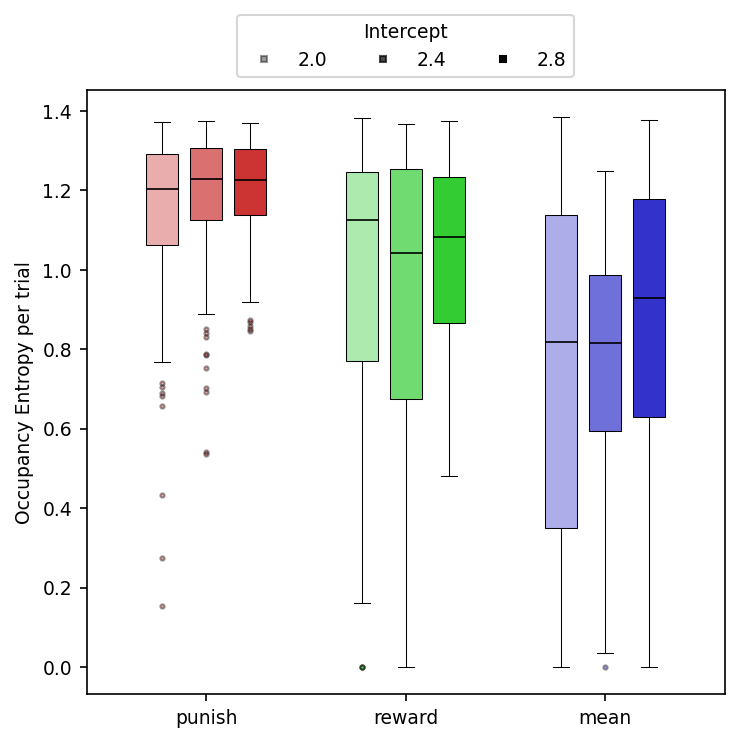

In [186]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Example setup (replace with your real data)
# traj_entropy = np.random.rand(2, 3, 3, 16)  # (subjects, methods, intercepts, trials)
colour = np.array([[0.8, 0.2, 0.2],   # punish: red
                   [0.2, 0.8, 0.2],   # reward: green
                   [0.2, 0.2, 0.8]])  # mean: blue
colour_factor = np.array([0.4, 0.7, 1.0])
methods = ["punish", "reward", "mean"]
intercepts = [2.0, 2.4, 2.8]

fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=150)

# --- Plot boxplots ---
positions = []
data = []
colors = []

for i in range(traj_entropy_2.shape[1]):  # methods
    for j in range(traj_entropy_2.shape[2]):  # intercepts
        pos = i*0.5 + 0.11 * j - 0.11
        positions.append(pos)
        data.append(traj_entropy_2[:, i, j, :].flatten())
        colors.append(np.clip(np.append(colour[i], colour_factor[j]), 0, 1))

# Create boxplots one by one for custom colors
for d, p, c in zip(data, positions, colors):
    bp = ax.boxplot(d, positions=[p], widths=0.08,
                    patch_artist=True, boxprops=dict(facecolor=c, color='k', linewidth=0.5),
                    medianprops=dict(color='k', linewidth=0.8),
                    whiskerprops=dict(color='k', linewidth=0.5),
                    capprops=dict(color='k', linewidth=0.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, markerfacecolor=c))

# ax.set_xlabel("method/intercept")
ax.set_ylabel("Occupancy Entropy per trial")

ax.set_xlim(-0.3,1.3)

# Adjust x-ticks for clarity
ax.set_xticks(np.arange(len(methods))*0.5)
ax.set_xticklabels(methods)

# --- Create legends ---
# Legend 1: methods (solid colors)
# method_handles = [
#     Line2D([0], [0], marker='s', color='none', markerfacecolor=colour[i],
#            markersize=8, label=methods[i])
#     for i in range(len(methods))
# ]

# Legend 2: intercepts (grayscale with opacity)
intercept_handles = [
    Line2D([0], [0], marker='s', color='none',
           markerfacecolor=(0, 0, 0, colour_factor[j]),
           markersize=3, label=f"{intercepts[j]}")
    for j in range(len(intercepts))
]

# Add legends separately
# legend1 = ax.legend(handles=method_handles, title="Method", loc='lower left')
# ax.add_artist(legend1)
ax.legend(handles=intercept_handles, title="Intercept", loc='upper center', bbox_to_anchor=(0.5, 1.14),
          ncol=3, fancybox=True)

plt.tight_layout()
plt.show()


In [187]:
traj_entropy_random = np.array([1.27464806, 1.07279419, 0.54145368, 1.10572385, 1.19627133,
       1.34305128, 0.68604735, 1.33926137, 1.21306739, 1.31927788,
       1.33555471, 1.21603471, 0.78959181, 0.69073863, 1.18840635,
       1.25630499, 1.23106023, 1.27291317, 0.89073858, 1.31205535,
       1.14996363, 1.12537096, 0.94468833, 1.32889365, 1.00765041,
       1.1833508 , 0.9205955 , 0.93579564, 0.92133596, 1.26478896,
       1.2182034 , 1.14398258, 1.14727154, 0.93151257, 1.29774647,
       1.37902768, 1.2151132 , 1.11514351, 1.18829867, 1.25649171,
       0.99648151, 1.27715746, 1.17483433, 1.07118989, 1.31557707,
       1.20709308, 0.70794327, 1.26183563, 1.37530457, 1.36564485,
       1.32359497, 0.90117368, 1.15890521, 1.20649979, 1.21282274])

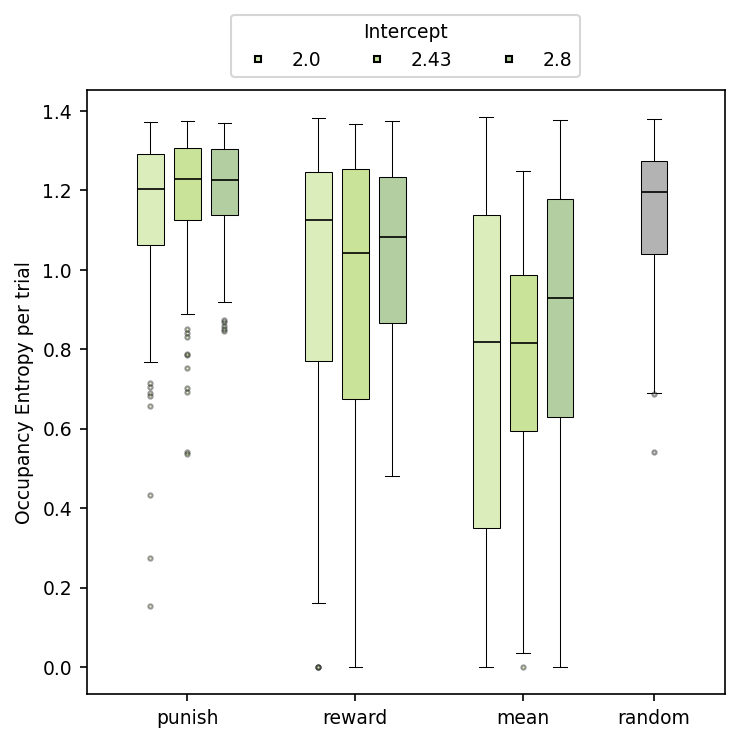

In [188]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Example setup (replace with your real data)
# traj_entropy = np.random.rand(2, 3, 3, 16)  # (subjects, methods, intercepts, trials)
# 3 fixed pastel colours for intercepts
intercept_colours = np.array([
    [0.86, 0.93, 0.73],       # lighter sage
    [0.79, 0.89, 0.60],   # base sage (#A1C698)
    [0.70, 0.81, 0.63]    # darker sage
])


colour_factor = np.array([0.4, 0.7, 1.0])
methods = ["punish", "reward", "mean", "random"]
intercepts = [2.0, 2.43, 2.8]

fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=150)

# --- Plot boxplots ---
positions = []
data = []
colors = []

for i in range(traj_entropy_2.shape[1]):  # methods
    for j in range(traj_entropy_2.shape[2]):  # intercepts
        pos = i*0.5 + 0.11 * j - 0.11
        positions.append(pos)
        data.append(traj_entropy_2[:, i, j, :].flatten())
        colors.append(intercept_colours[j])


# -----------------------------
# Add the "random" method box
# -----------------------------
i = 3  # 4th method index
p = i * 0.5 - 0.11  # place it at regular method spacing
positions.append(p)

# flatten the random array (shape n)
data.append(traj_entropy_random.flatten())

# choose color for this method
colors.append([0.7, 0.7, 0.7])



# Create boxplots one by one for custom colors
for d, p, c in zip(data, positions, colors):
    bp = ax.boxplot(d, positions=[p], widths=0.08,
                    patch_artist=True, boxprops=dict(facecolor=c, color='k', linewidth=0.5),
                    medianprops=dict(color='k', linewidth=0.8),
                    whiskerprops=dict(color='k', linewidth=0.5),
                    capprops=dict(color='k', linewidth=0.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.4, markerfacecolor=c))

# ax.set_xlabel("method/intercept")
ax.set_ylabel("Occupancy Entropy per trial")

ax.set_xlim(-0.3,1.6)

# Adjust x-ticks for clarity
xrange = np.arange(len(methods)) * 0.5
xrange[-1] -= 0.11
ax.set_xticks(xrange)
ax.set_xticklabels(methods)


# --- Create legends ---
# Legend 1: methods (solid colors)
# method_handles = [
#     Line2D([0], [0], marker='s', color='none', markerfacecolor=colour[i],
#            markersize=8, label=methods[i])
#     for i in range(len(methods))
# ]

# Legend 2: intercepts (grayscale with opacity)
intercept_handles = [
    Line2D([0], [0], marker='s', color='none',
           markerfacecolor=(intercept_colours[j]),
           markersize=3, label=f"{intercepts[j]}")
    for j in range(len(intercepts))
]

# Add legends separately
# legend1 = ax.legend(handles=method_handles, title="Method", loc='lower left')
# ax.add_artist(legend1)
ax.legend(handles=intercept_handles, title="Intercept", loc='upper center', bbox_to_anchor=(0.5, 1.14),
          ncol=3, fancybox=True)

plt.tight_layout()
plt.savefig("occupancy_entropy.svg")
plt.show()


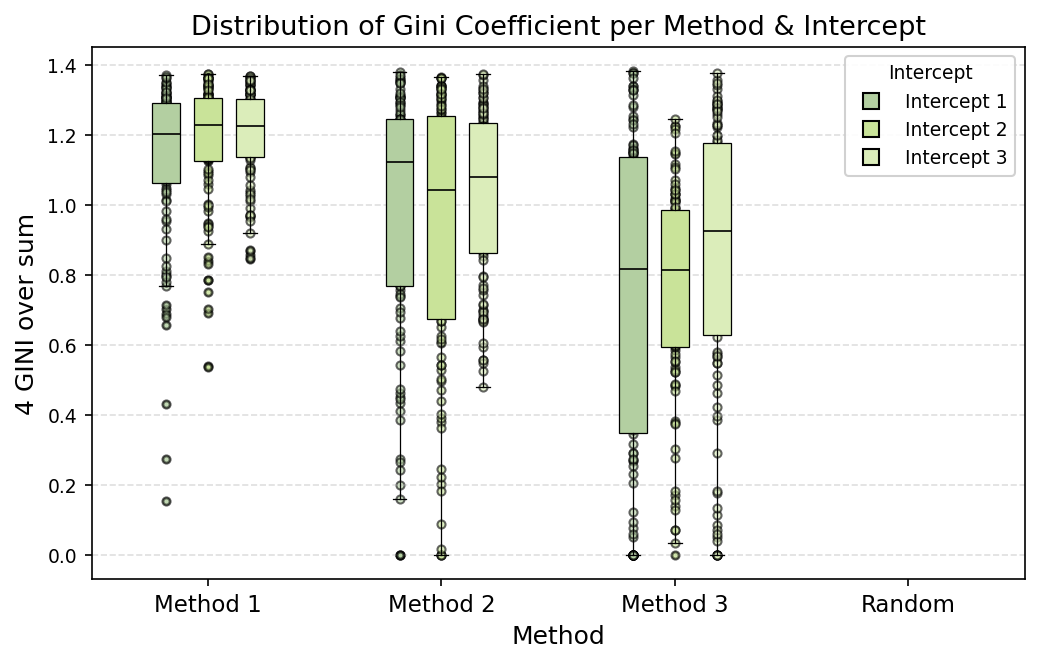

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Example arrays (replace with your data)
# traj_entropy_2.shape = (n_seeds, n_methods, n_intercepts, n_trials)
# colour = pastel colours per method
# intercept_colours = 3 pastel tones for intercepts

# Define pastel colours (sandy-brown or #A1C698 tones)
colour = np.array([
    [0.70, 0.81, 0.63],  # method 1
    [0.70, 0.81, 0.63],  # method 2
    [0.70, 0.81, 0.63],  # method 3
    [0.7, 0.7, 0.7]      # method 4 (random)
])
intercept_colours = np.array([
    [0.70, 0.81, 0.63],   # light
    [0.79, 0.89, 0.60],   # medium
    [0.86, 0.93, 0.73]    # dark
])

fig, ax = plt.subplots(1, 1, figsize=(7, 4.5), dpi=150)

n_methods = traj_entropy_2.shape[1]
n_intercepts = traj_entropy_2.shape[2]
offset = 0.18  # horizontal spacing for intercepts within each method

# --- Plot boxplots ---
for i in range(n_methods):
    for j in range(n_intercepts):
        x_pos = i + (j - (n_intercepts-1)/2)*offset
        data = traj_entropy_2[:, i, j, :].flatten()
        bp = ax.boxplot(
            data,
            positions=[x_pos],
            widths=0.12,
            patch_artist=True,
            medianprops=dict(color='k', linewidth=0.8),
            boxprops=dict(facecolor=intercept_colours[j], color='k', linewidth=0.6),
            whiskerprops=dict(color='k', linewidth=0.6),
            capprops=dict(color='k', linewidth=0.6),
            flierprops=dict(marker='o', markersize=3, alpha=0.5, markerfacecolor=intercept_colours[j])
        )
        # Overlay individual points for better visualization
        ax.scatter(
            np.full_like(data, x_pos),
            data,
            color=intercept_colours[j],
            edgecolor='k',
            alpha=0.6,
            s=15
        )

# --- Axes styling ---
ax.set_xticks(range(n_methods+1))
ax.set_xticklabels(['Method 1', 'Method 2', 'Method 3', 'Random'], fontsize=11)
ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('4 GINI over sum', fontsize=12)
ax.set_title('Distribution of Gini Coefficient per Method & Intercept', fontsize=13)

# Gridlines
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.set_xlim(-0.5, n_methods+1-0.5)

# Legend for intercept colours
intercept_handles = [
    Line2D([0], [0], marker='s', color='none', markerfacecolor=intercept_colours[j],
           markersize=8, label=f'Intercept {j+1}') for j in range(n_intercepts)
]
ax.legend(handles=intercept_handles, title='Intercept', loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()


In [ ]:
percent_active_all = [0.07903842] # random
population_ratio = [1.7997661069288087] # random